# Wildfire Evacuation Community Resource Matching
## Census Tract Demographic Flag Analysis
### WiDS Datathon 2026 — Route 1: Accelerating Equitable Evacuations

---
**Project Name:** *CERM- Community Evacuation Resource Matching*

**Team Name:** *Ramblin' Pathfinders*

**University:** *Georgia Institute of Technology*

**Course:** *MS in Analytics*

**Term:** *Semester 2, Year 1 Masters*

**Team Members:**
- Riya Bharathwaj
- Ting-ya Chang
- Saehee Eom
- Tanmayee Kolli
- Simran Mallik

---

## Overview

This notebook prepares the **demographic foundation** for the Community Evacuation Resource Matcher (CERM) — an interactive web tool that connects community helpers with census tracts most in need during wildfire evacuations.

### Pipeline Summary

1. Pull California census tract demographic data from the **ACS 5-Year Survey (2023)**
2. Merge with **TIGER/Line tract shapefiles** for spatial context
3. Conduct **statewide EDA** to understand baseline distributions across all CA tracts
4. Select counties with sufficient size and internal demographic variability
5. Conduct **county-specific EDA** on each selected county to characterize local patterns
6. Apply **per-county Q3 threshold flagging** to identify tracts with elevated vulnerability
7. Export a **CSV** (for the LLM matching pipeline) and a **GeoJSON** (for the web map)

### Why This Matters

Wildfire evacuations disproportionately burden communities with limited mobility, health vulnerabilities, or resource constraints. By identifying which census tracts have the highest concentrations of elderly residents, people with disabilities, and households without vehicles, we can direct volunteer resources where they are needed most — before, during, and after an evacuation event.

### Link to Project Writeup
> *(Add link to your team's writeup or slide deck here)*

### Link to Prototype
> *(https://riyabharath24.github.io/cerm-wildfire-evacuation-tool/)*
---

## Section 1 · Data Acquisition

### Census API Pull (Reference)

The cell below shows how the raw ACS demographic data was originally fetched from the **Census Bureau API**. It is commented out since the output CSV is already saved locally — but included here for full reproducibility.

**API endpoint:** `ACS 5-Year Data Profiles (2023)` — tables `DP02` (Social) and `DP04` (Housing)
**Geographic scope:** All census tracts in California (`state:06`)

| ACS Variable | Description |
|---|---|
| `DP02_0015PE` | % Households with a person 65+ (Elderly) |
| `DP02_0072PE` | % Population with a disability |
| `DP02_0022PE` | % Households with children under 18 |
| `DP04_0058PE` | % Households without a vehicle |
| `DP05_0001E` | Total population |

In [1]:
# --- DATA ACQUISITION (run once to regenerate the raw CSV) ---
# Fetches demographic data for all California census tracts
# from the Census Bureau ACS 5-Year API (2023 release).

import requests
import pandas as pd

url = (
    "https://api.census.gov/data/2023/acs/acs5/profile"
    "?get=NAME,GEO_ID,DP02_0015PE,DP02_0072PE,DP02_0022PE,DP04_0058PE,DP05_0001E"
    "&for=tract:*&in=state:06"
)

response = requests.get(url)
data = response.json()

# First row is the column header
df = pd.DataFrame(data[1:], columns=data[0])
df.to_csv('CA Census Tract Demographic Info.csv', index=False)
print(f'Saved {len(df):,} rows to CA Census Tract Demographic Info.csv')

Saved 9,129 rows to CA Census Tract Demographic Info.csv


---
## Section 2 · Imports & Configuration

All dependencies are standard geospatial and data science libraries available in Colab.
`geopandas` handles the spatial merge and GeoJSON export; `sklearn` is used later for
normalizing county suitability scores.

In [2]:
# Importing the required libraries
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import warnings
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

---
## Section 3 · File Paths & County Reference Table

### Input Files

| File | Source | Description |
|---|---|---|
| `CA Census Tract Demographic Info.csv` | Census API (Section 1) | ACS demographic variables for all CA tracts |
| `tl_2025_06_tract.shp` | [Census TIGER/Line](https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html) | Tract polygon boundaries for California |

> **Colab users:** Upload both files to your session storage, or mount Google Drive and update the paths below.

### California County FIPS Reference

The `CA_COUNTIES` dictionary maps 3-digit FIPS codes to human-readable county names used throughout this notebook.

In [3]:
# ── File paths ────────────────────────────────────────────────────────────
# Update these if running in Colab with Drive mount:
#   census_demo_path = '/content/drive/MyDrive/WiDS/CA Census Tract Demographic Info.csv'
#   tracts_path      = '/content/drive/MyDrive/WiDS/tl_2025_06_tract/tl_2025_06_tract.shp'

census_demo_path = 'CA Census Tract Demographic Info.csv'
tracts_path      = 'tl_2025_06_tract/tl_2025_06_tract.shp'

# ── California County FIPS → display name lookup ──────────────────────────
CA_COUNTIES = {
    '001': ('Alameda',        'Alameda County, California, USA'),
    '003': ('Alpine',         'Alpine County, California, USA'),
    '005': ('Amador',         'Amador County, California, USA'),
    '007': ('Butte',          'Butte County, California, USA'),
    '009': ('Calaveras',      'Calaveras County, California, USA'),
    '011': ('Colusa',         'Colusa County, California, USA'),
    '013': ('Contra Costa',   'Contra Costa County, California, USA'),
    '015': ('Del Norte',      'Del Norte County, California, USA'),
    '017': ('El Dorado',      'El Dorado County, California, USA'),
    '019': ('Fresno',         'Fresno County, California, USA'),
    '021': ('Glenn',          'Glenn County, California, USA'),
    '023': ('Humboldt',       'Humboldt County, California, USA'),
    '025': ('Imperial',       'Imperial County, California, USA'),
    '027': ('Inyo',           'Inyo County, California, USA'),
    '029': ('Kern',           'Kern County, California, USA'),
    '031': ('Kings',          'Kings County, California, USA'),
    '033': ('Lake',           'Lake County, California, USA'),
    '035': ('Lassen',         'Lassen County, California, USA'),
    '037': ('Los Angeles',    'Los Angeles County, California, USA'),
    '039': ('Madera',         'Madera County, California, USA'),
    '041': ('Marin',          'Marin County, California, USA'),
    '043': ('Mariposa',       'Mariposa County, California, USA'),
    '045': ('Mendocino',      'Mendocino County, California, USA'),
    '047': ('Merced',         'Merced County, California, USA'),
    '049': ('Modoc',          'Modoc County, California, USA'),
    '051': ('Mono',           'Mono County, California, USA'),
    '053': ('Monterey',       'Monterey County, California, USA'),
    '055': ('Napa',           'Napa County, California, USA'),
    '057': ('Nevada',         'Nevada County, California, USA'),
    '059': ('Orange',         'Orange County, California, USA'),
    '061': ('Placer',         'Placer County, California, USA'),
    '063': ('Plumas',         'Plumas County, California, USA'),
    '065': ('Riverside',      'Riverside County, California, USA'),
    '067': ('Sacramento',     'Sacramento County, California, USA'),
    '069': ('San Benito',     'San Benito County, California, USA'),
    '071': ('San Bernardino', 'San Bernardino County, California, USA'),
    '073': ('San Diego',      'San Diego County, California, USA'),
    '075': ('San Francisco',  'San Francisco County, California, USA'),
    '077': ('San Joaquin',    'San Joaquin County, California, USA'),
    '079': ('San Luis Obispo','San Luis Obispo County, California, USA'),
    '081': ('San Mateo',      'San Mateo County, California, USA'),
    '083': ('Santa Barbara',  'Santa Barbara County, California, USA'),
    '085': ('Santa Clara',    'Santa Clara County, California, USA'),
    '087': ('Santa Cruz',     'Santa Cruz County, California, USA'),
    '089': ('Shasta',         'Shasta County, California, USA'),
    '091': ('Sierra',         'Sierra County, California, USA'),
    '093': ('Siskiyou',       'Siskiyou County, California, USA'),
    '095': ('Solano',         'Solano County, California, USA'),
    '097': ('Sonoma',         'Sonoma County, California, USA'),
    '099': ('Stanislaus',     'Stanislaus County, California, USA'),
    '101': ('Sutter',         'Sutter County, California, USA'),
    '103': ('Tehama',         'Tehama County, California, USA'),
    '105': ('Trinity',        'Trinity County, California, USA'),
    '107': ('Tulare',         'Tulare County, California, USA'),
    '109': ('Tuolumne',       'Tuolumne County, California, USA'),
    '111': ('Ventura',        'Ventura County, California, USA'),
    '113': ('Yolo',           'Yolo County, California, USA'),
    '115': ('Yuba',           'Yuba County, California, USA'),
}
COUNTY_NAMES = {fips: name for fips, (name, _) in CA_COUNTIES.items()}
print(f"County reference loaded: {len(CA_COUNTIES)} California counties")

County reference loaded: 58 California counties


---
## Section 4 · Load & Clean Census Tract Data

### 4.1 Load ACS Demographics

The raw ACS CSV has two quirks we handle here:
- **Row 0 is a duplicate header** — dropped via `.loc[1:, :]`
- **GEO_ID has a `1400000US` prefix** — stripped to get the bare 11-digit FIPS GEOID (e.g. `06007000100`)

Column names are renamed from cryptic ACS variable codes to descriptive labels.

In [4]:
# Reading the CA Census tract data
ca_census = pd.read_csv(census_demo_path).copy().loc[1:, :]

# Strip the '1400000US' prefix to get the bare 11-digit GEOID
ca_census['GEOID'] = ca_census['GEO_ID'].str.replace('^1400000US', '', regex=True)

# Rename ACS variable codes to human-readable labels
ca_census = ca_census.rename(columns={
    'DP02_0015PE': 'Percent of Households with Elderly',
    'DP02_0072PE': 'Percent of Population with Disability',
    'DP02_0022PE': 'Percent of Households with Children',
    'DP04_0058PE': 'Percent of Households without Vehicle',
    'DP05_0001E' : 'Total Population',
})

### 4.2 Merge with TIGER/Line Shapefiles

We join the ACS demographics to Census TIGER/Line tract boundaries on the shared `GEOID` key.
The GeoDataFrame is reprojected to **EPSG:4326** (WGS 84) — required for GeoJSON export and web map compatibility.

**Sentinel value handling:** ACS uses large negative integers (`-666666666`, `-999999999`) to mark suppressed or missing data. These are replaced with `NaN`.

In [6]:
# Reading the Census Tract line boundaries
tracts_shp = gpd.read_file(tracts_path)
tracts_shp['GEOID'] = tracts_shp['GEOID'].astype(str)

census_tract_info = pd.merge(ca_census, tracts_shp, how='left', on='GEOID')
census_tract_info = census_tract_info[[
    'NAME_x', 'GEOID',
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households with Children',
    'Percent of Households without Vehicle',
    'Total Population',
    'state', 'county', 'tract', 'geometry',
]].rename(columns={'NAME_x': 'NAME'})

census_tract_gdf = gpd.GeoDataFrame(census_tract_info.copy(), geometry='geometry', crs=tracts_shp.crs)
census_tract_gdf = census_tract_gdf.to_crs('EPSG:4326')

# ACS sentinel values → NaN, then cast to numeric
sentinel_values = [-666666666, -999999999]
dem_cols = [
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
]
for c in dem_cols:
    census_tract_gdf[c] = (
        pd.to_numeric(census_tract_gdf[c], errors='coerce')
        .replace(sentinel_values, np.nan)
    )

census_tract_gdf['Total Population'] = pd.to_numeric(
    census_tract_gdf['Total Population'], errors='coerce'
)

print(f'Census tracts loaded and merged: {len(census_tract_gdf):,} tracts')

Census tracts loaded and merged: 9,128 tracts


### 4.3 Missing Data Audit

Before dropping anything, we audit where nulls appear, by each census tract column. We then proceed to drop these null columns to aboid deviations in the data and to keep it clearn. 

In [7]:
# Overall null count per column
census_tract_gdf.isnull().sum()[census_tract_gdf.isnull().sum() > 0]

Percent of Households with Elderly       83
Percent of Population with Disability    71
Percent of Households without Vehicle    83
dtype: int64

In [8]:
# Dropping all columns with null values
before = len(census_tract_gdf)
census_tract_gdf = census_tract_gdf.dropna(subset=dem_cols).copy()
after  = len(census_tract_gdf)
dropped = before - after
print(f'Tracts before drop : {before:,}')
print(f'Tracts after drop  : {after:,}  ({dropped:,} removed — {dropped/before*100:.1f}%)')

Tracts before drop : 9,128
Tracts after drop  : 9,045  (83 removed — 0.9%)


---
## Section 5 · Statewide EDA

Before narrowing to specific counties, we explore the **full California dataset** to establish
baseline distributions for each demographic variable. These statewide patterns serve as the
reference point for interpreting county-level differences in Section 7.

### Summary Statistics

In [9]:
census_tract_gdf.describe()

,Percent of Households with Elderly,Percent of Population with Disability,Percent of Households with Children,Percent of Households without Vehicle,Total Population,state,county,tract
count,9045.00,9045.00,9045.00,9045.00,9045.00,9045.00,9045.00,9045.00
mean,31.79,11.62,29.67,7.15,4327.99,6.00,55.29,190743.46
std,12.46,5.25,8.66,8.78,1725.13,0.00,26.69,234197.18
min,0.00,0.00,0.00,0.00,9.00,6.00,1.00,100.00
25%,23.50,8.20,25.30,2.00,3153.00,6.00,37.00,8359.00
50%,30.90,10.80,30.70,4.60,4169.00,6.00,59.00,52421.00
75%,39.10,14.00,35.30,9.10,5344.00,6.00,73.00,400602.00
max,100.00,89.20,73.90,100.00,40481.00,6.00,115.00,988300.00


### 5.1 Distribution — Percent of Households with Elderly

Histograms use 5-percentage-point bins (`-10` to `100`) to reveal the shape of each
distribution across all ~8,000 California census tracts.

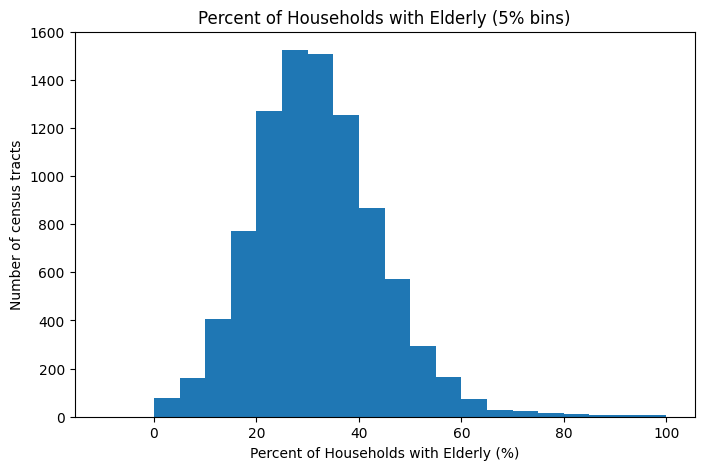

In [10]:
col = "Percent of Households with Elderly"
x = pd.to_numeric(census_tract_gdf[col], errors="coerce")

bins = list(range(-10, 101, 5))

plt.figure(figsize=(8,5))
plt.hist(x.dropna(), bins=bins)
plt.xlabel(col + " (%)")
plt.ylabel("Number of census tracts")
plt.title(f"{col} (5% bins)")
plt.show()

**Observation:** The distribution of elderly household percentage is approximately normally distributed statewide, with the mean centered around 32%. Most California census tracts fall in the 20–45% range, with a thin tail on both ends.

### 5.2 Distribution — Percent of Population with Disability

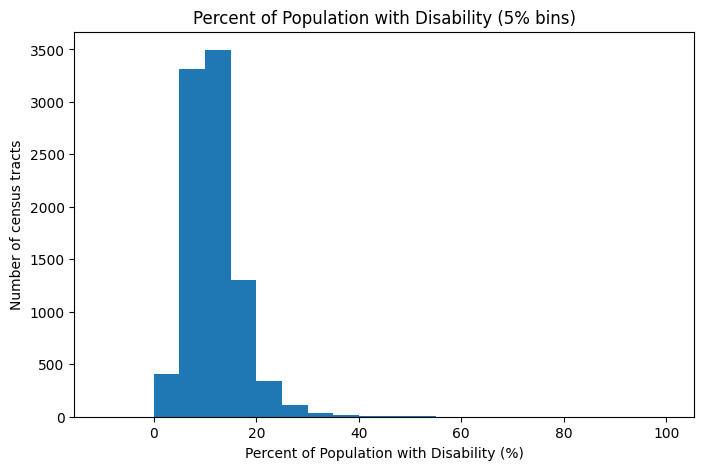

In [11]:
col = "Percent of Population with Disability"
x = pd.to_numeric(census_tract_gdf[col], errors="coerce")

bins = list(range(-10, 101, 5))

plt.figure(figsize=(8,5))
plt.hist(x.dropna(), bins=bins)
plt.xlabel(col + " (%)")
plt.ylabel("Number of census tracts")
plt.title(f"{col} (5% bins)")
plt.show()

**Observation:** The disability distribution is right-skewed, with the bulk of California census tracts concentrated in the 5–15% range and a notable long tail extending to around 50%. The peak falls in the 10–15% bin. This skew means that while low disability rates are the norm across most of the state, a meaningful number of tracts have substantially elevated rates — and the Q3 cutoff of ~14% captures the threshold above which tracts genuinely stand out from their peers.

### 5.3 Distribution — Percent of Households without Vehicle

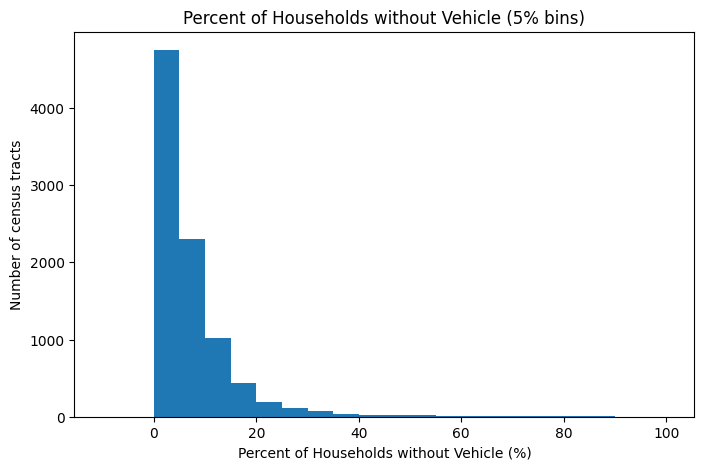

In [12]:
col = "Percent of Households without Vehicle"
x = pd.to_numeric(census_tract_gdf[col], errors="coerce")

bins = list(range(-10, 101, 5))

plt.figure(figsize=(8,5))
plt.hist(x.dropna(), bins=bins)
plt.xlabel(col + " (%)")
plt.ylabel("Number of census tracts")
plt.title(f"{col} (5% bins)")
plt.show()

**Observation:** The no-vehicle distribution is strongly right-skewed, with the vast majority of California census tracts below 10%. The tail extends sparsely past 40%, with just a handful of tracts reaching 60–80%+. This reflects California's overwhelmingly car-dependent built environment — car-free households are rare in most of the state, but a small number of dense urban tracts deviate sharply from that pattern.

### 5.4 Statewide Correlation Heatmap

We compute the **Pearson correlation** between all four demographic variables to understand which dimensions co-vary across California tracts. This informs our interpretation of the flag co-occurrence patterns later in Section 9.

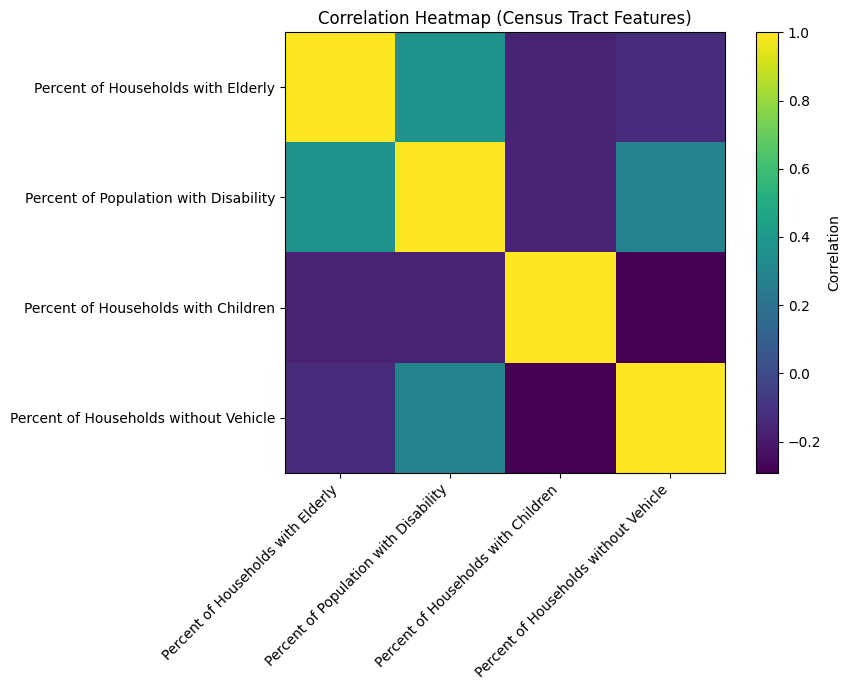

In [13]:
cols = [
    "Percent of Households with Elderly",
    "Percent of Population with Disability",
    "Percent of Households with Children",
    "Percent of Households without Vehicle"
]

df_corr = census_tract_gdf[cols].copy()
for c in cols:
    df_corr[c] = pd.to_numeric(df_corr[c], errors="coerce")

sentinels = [-666666666, -999999999]
df_corr = df_corr.replace(sentinels, np.nan)

corr = df_corr.corr(method="pearson")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values)

ax.set_xticks(range(len(cols)))
ax.set_yticks(range(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

ax.set_title("Correlation Heatmap (Census Tract Features)")
plt.tight_layout()
plt.show()

**Observation:** There is a moderate positive correlation between *Percent of Population with Disability* and *Percent of Households with Elderly*, and between *Percent of Households without Vehicle* and *Percent of Population with Disability*. This is consistent with the reality that elderly residents may drive less due to physical limitations, and that people with disabilities may also face barriers to vehicle access or ownership. Importantly, **no pairwise correlation exceeds 0.5**, meaning the three flag variables capture meaningfully distinct dimensions of vulnerability — they are related but not redundant.

---
## Section 6 · County Selection

### Motivation

California has 58 counties ranging enormously in size, density, and demographics.
Using statewide thresholds for flagging would be misleading — a "high elderly" cutoff
calibrated to Los Angeles tells us nothing useful about Butte County.

We select a focused subset of counties that are:
1. **Large enough(≥ 50 census tracts):** for Q3 thresholds to be statistically meaningful
2. **Demographically heterogeneous:** Enough internal variation for flags to distinguish tracts
3. **High-need:** Above-average rates of the vulnerability dimensions we care about

### Scoring Approach

Counties passing the size and heterogeneity filters are **ranked by a composite suitability score**:
a normalized sum of mean vulnerability and standard deviation across all three dimensions.
This rewards counties that are both high-need *and* varied enough for flagging to be informative.

In [14]:
vars_of_interest = [
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
]

df = census_tract_gdf.copy()
for v in vars_of_interest:
    df[v] = pd.to_numeric(df[v], errors='coerce')

county_summary = (
    df
    .groupby('county')
    .agg(
        n_tracts        = ('GEOID',                                 'count'),
        elderly_mean    = ('Percent of Households with Elderly',    'mean'),
        elderly_std     = ('Percent of Households with Elderly',    'std'),
        disability_mean = ('Percent of Population with Disability', 'mean'),
        disability_std  = ('Percent of Population with Disability', 'std'),
        novehicle_mean  = ('Percent of Households without Vehicle', 'mean'),
        novehicle_std   = ('Percent of Households without Vehicle', 'std'),
    )
    .reset_index()
)

county_summary['county_fips'] = county_summary['county'].astype(str).str.zfill(3)
county_summary['county_name'] = county_summary['county_fips'].map(
    lambda f: COUNTY_NAMES.get(f, f'County {f}')
)

# Filter: ≥50 tracts AND heterogeneity in at least one dimension
county_filtered = county_summary[
    (county_summary['n_tracts'] >= 50) &
    (
        (county_summary['elderly_std']    >= 3) |
        (county_summary['disability_std'] >= 2) |
        (county_summary['novehicle_std']  >= 2)
    )
].copy()

print(f'Counties passing filter: {len(county_filtered)} / {len(county_summary)}')
display(
    county_filtered[['county_name', 'n_tracts', 'elderly_std', 'disability_std', 'novehicle_std']]
    .sort_values('county_name')
)

Counties passing filter: 30 / 58


,county_name,n_tracts,elderly_std,disability_std,novehicle_std
0,Alameda,376,10.24,4.61,10.94
3,Butte,54,14.36,6.98,4.35
6,Contra Costa,240,13.01,5.25,4.47
8,El Dorado,54,11.89,5.00,3.97
9,Fresno,225,10.26,5.36,7.24
14,Kern,232,11.84,5.94,6.20
18,Los Angeles,2469,11.42,4.53,8.90
20,Marin,62,12.41,4.16,5.66
23,Merced,63,7.53,4.34,5.59
26,Monterey,100,15.88,4.80,3.86


In [15]:
score_vars = [
    'elderly_mean',    'elderly_std',
    'disability_mean', 'disability_std',
    'novehicle_mean',  'novehicle_std',
]

X        = county_filtered[score_vars].values
X_scaled = StandardScaler().fit_transform(X)
county_filtered = county_filtered.copy()
county_filtered['suitability_score'] = X_scaled.sum(axis=1)

In [16]:
# ── Adjust N_COUNTIES to select more or fewer counties ────────────────────
N_COUNTIES = 5
# ─────────────────────────────────────────────────────────────────────────

top_counties     = county_filtered.sort_values('suitability_score', ascending=False).head(N_COUNTIES)
top_county_fips  = top_counties['county_fips'].tolist()
top_county_names = top_counties['county_name'].tolist()

print(f'Top {N_COUNTIES} selected counties:')
for _, row in top_counties.iterrows():
    print(f"  {row['county_name']:20s}  suitability={row['suitability_score']:.3f}  n_tracts={int(row['n_tracts'])}")

Top 5 selected counties:
  San Francisco         suitability=12.393  n_tracts=240
  Butte                 suitability=5.855  n_tracts=54
  Shasta                suitability=4.163  n_tracts=50
  Placer                suitability=2.987  n_tracts=91
  Riverside             suitability=2.300  n_tracts=516


---
## Section 7 · Finalize Tract Dataset

Filter the full California GeoDataFrame down to our selected counties and attach
human-readable county names. This is the working dataset for all county-level EDA,
flagging, and visualization steps that follow.

In [17]:
# Filter to selected counties only
tracts = census_tract_gdf[
    census_tract_gdf['county'].astype(str).str.zfill(3).isin(top_county_fips)
].copy()

# Attach county name for readability
tracts['county_fips'] = tracts['county'].astype(str).str.zfill(3)
tracts['county_name'] = tracts['county_fips'].map(lambda f: COUNTY_NAMES.get(f, f))

print(f'Final working dataset: {len(tracts):,} tracts across {tracts["county_name"].nunique()} counties')
print(tracts['county_name'].value_counts().rename('Tract Count').to_string())

Final working dataset: 951 tracts across 5 counties
county_name
Riverside        516
San Francisco    240
Placer            91
Butte             54
Shasta            50


---
## Section 8 · County-Specific EDA

Having established statewide baselines in Section 5, we now examine each selected county individually.
The goal is to understand how each county's demographic distributions compare to the statewide picture,
and to identify any local patterns that would affect how we interpret flagging results.

### Reusable EDA Function

The `eda_plots_for_county()` function below generates three outputs for any county:
1. **Histograms** for each demographic percentage variable (5% bins)
2. **Correlation heatmap** between all three vulnerability dimensions
3. **Choropleth maps** showing the spatial distribution of each variable across the county's tracts

We use **Spearman correlation** at the county level (instead of Pearson) because within-county
distributions are often skewed, and Spearman is more robust to outliers and non-normality.

In [18]:
plt.rcParams.update({
    "figure.figsize": (14, 8),
    "figure.dpi": 120,
    "font.size": 13,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

def eda_plots_for_county(
    census_tract_gdf: gpd.GeoDataFrame,
    county_fips: str = '075',
    pct_bins=None,
    sentinels=None,
    corr_method: str = "pearson",
    make_static_maps: bool = True,
    map_vars=None
):
    """
    Produce static EDA plots for a single county (by FIPS in the 'county' column).

    Outputs:
      - Histograms for ACS % variables (5% bins)
      - Correlation heatmap among selected variables
      - Optional static choropleth maps for each variable

    Parameters:
      census_tract_gdf : GeoDataFrame with ACS data for all CA tracts
      county_fips      : 3-digit FIPS string (e.g. '065' for Riverside)
      corr_method      : 'pearson' or 'spearman'
      make_static_maps : whether to render choropleth maps (can be slow for large counties)
    """
    if sentinels is None:
        sentinels = [-666666666, -999999999]
    if pct_bins is None:
        pct_bins = list(range(-10, 101, 5))

    pct_cols = [
        "Percent of Households with Elderly",
        "Percent of Population with Disability",
        "Percent of Households without Vehicle",
    ]
    if map_vars is None:
        map_vars = pct_cols

    # Filter to county
    gdf = census_tract_gdf.copy()
    gdf["county_fips"] = gdf["county"].astype(str).str.zfill(3)
    county_gdf = gdf.loc[gdf["county_fips"] == str(county_fips).zfill(3)].copy()
    print(f"County FIPS {str(county_fips).zfill(3)} — {len(county_gdf)} tracts")

    if county_gdf.empty:
        raise ValueError("No rows found for that county FIPS.")

    # Clean numeric columns
    for c in pct_cols:
        if c in county_gdf.columns:
            county_gdf[c] = pd.to_numeric(county_gdf[c], errors="coerce").replace(sentinels, np.nan)

    # 1) Histograms
    for col in pct_cols:
        if col not in county_gdf.columns:
            continue
        x = county_gdf[col].dropna()
        plt.figure(figsize=(8, 5))
        plt.hist(x, bins=pct_bins)
        plt.xlabel(col + " (%)")
        plt.ylabel("Number of census tracts")
        plt.title(f"{col} (5% bins) — County {str(county_fips).zfill(3)}")
        plt.show()

    # 2) Correlation heatmap
    available_corr_cols = [c for c in pct_cols if c in county_gdf.columns]
    df_corr = county_gdf[available_corr_cols].copy()
    for c in available_corr_cols:
        df_corr[c] = pd.to_numeric(df_corr[c], errors="coerce").replace(sentinels, np.nan)
    corr = df_corr.corr(method=corr_method)

    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr.values)
    ax.set_xticks(range(len(available_corr_cols)))
    ax.set_yticks(range(len(available_corr_cols)))
    ax.set_xticklabels(available_corr_cols, rotation=45, ha="right")
    ax.set_yticklabels(available_corr_cols)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f"Correlation ({corr_method})")
    ax.set_title(f"Correlation Heatmap — County {str(county_fips).zfill(3)}")
    plt.tight_layout()
    plt.show()

    # 3) Optional static choropleth maps
    if make_static_maps:
        if county_gdf.crs is None:
            print("Warning: no CRS set — maps may not plot correctly.")
        elif county_gdf.crs.to_string() != "EPSG:4326":
            county_gdf = county_gdf.to_crs("EPSG:4326")
        for v in map_vars:
            if v not in county_gdf.columns:
                continue
            fig, ax = plt.subplots(1, 1, figsize=(8, 8))
            county_gdf.plot(
                column=v, ax=ax, legend=True, cmap="Blues",
                missing_kwds={"color": "lightgrey"},
                legend_kwds={"shrink": 0.6},
            )
            ax.set_title(f"{v} — County {str(county_fips).zfill(3)}")
            ax.axis("off")
            plt.show()

    return county_gdf

### 8.1 Riverside County (FIPS: 065)

Riverside is a large inland Southern California county characterized by suburban and exurban development,
significant retirement communities in the Coachella Valley, and strong car-dependence throughout.

County FIPS 065 — 516 tracts


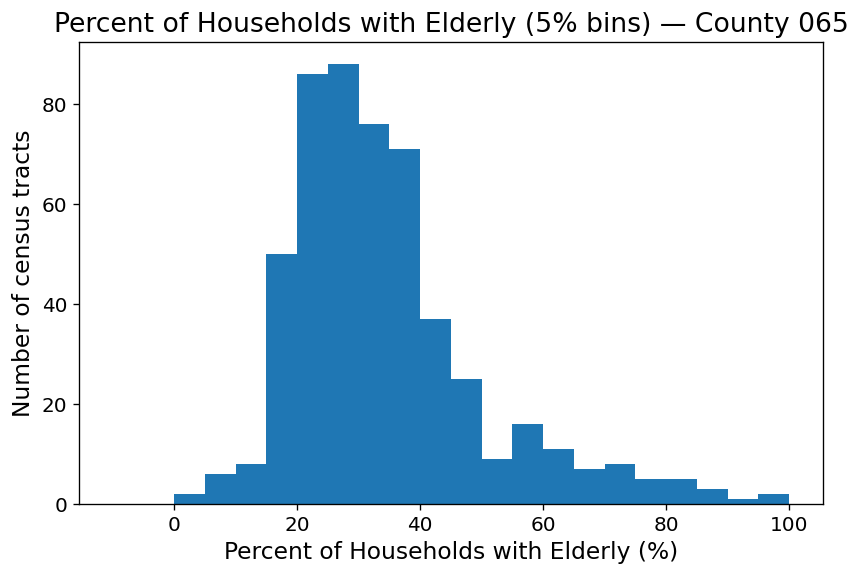

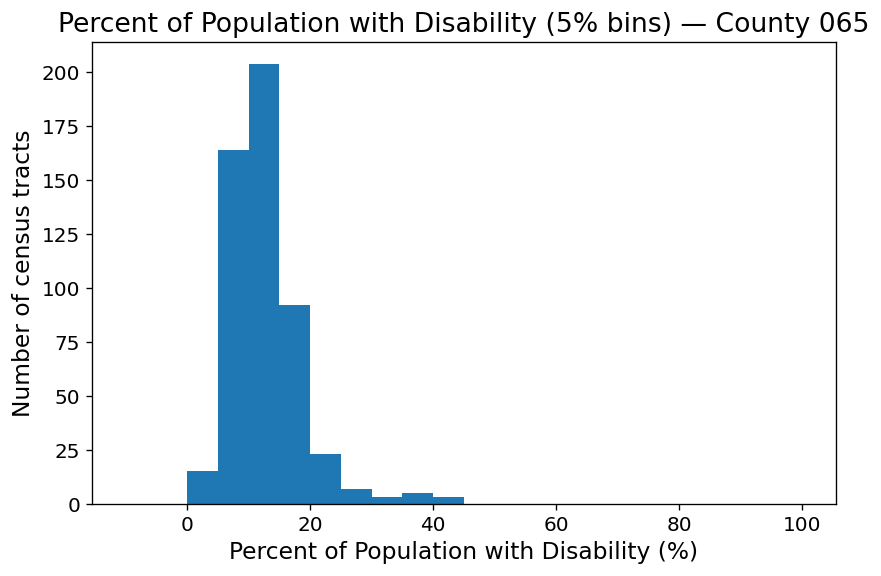

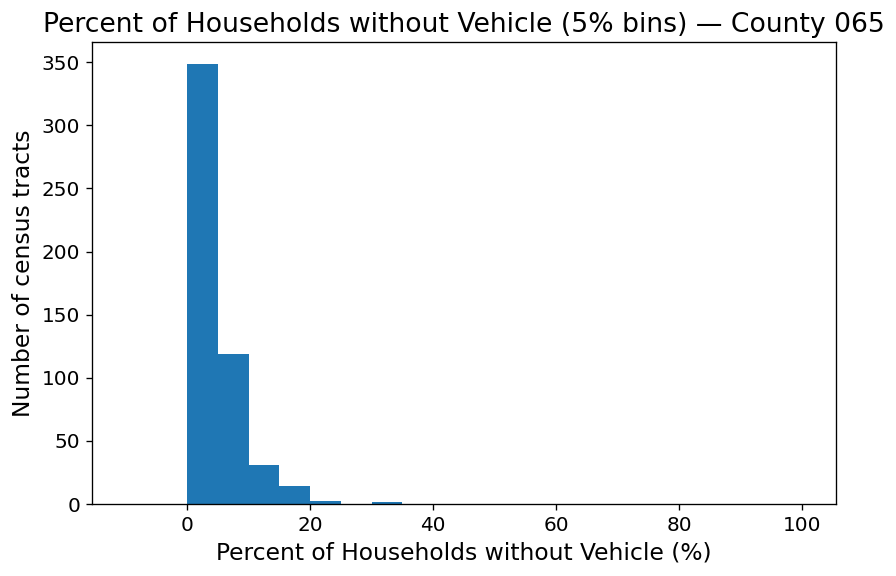

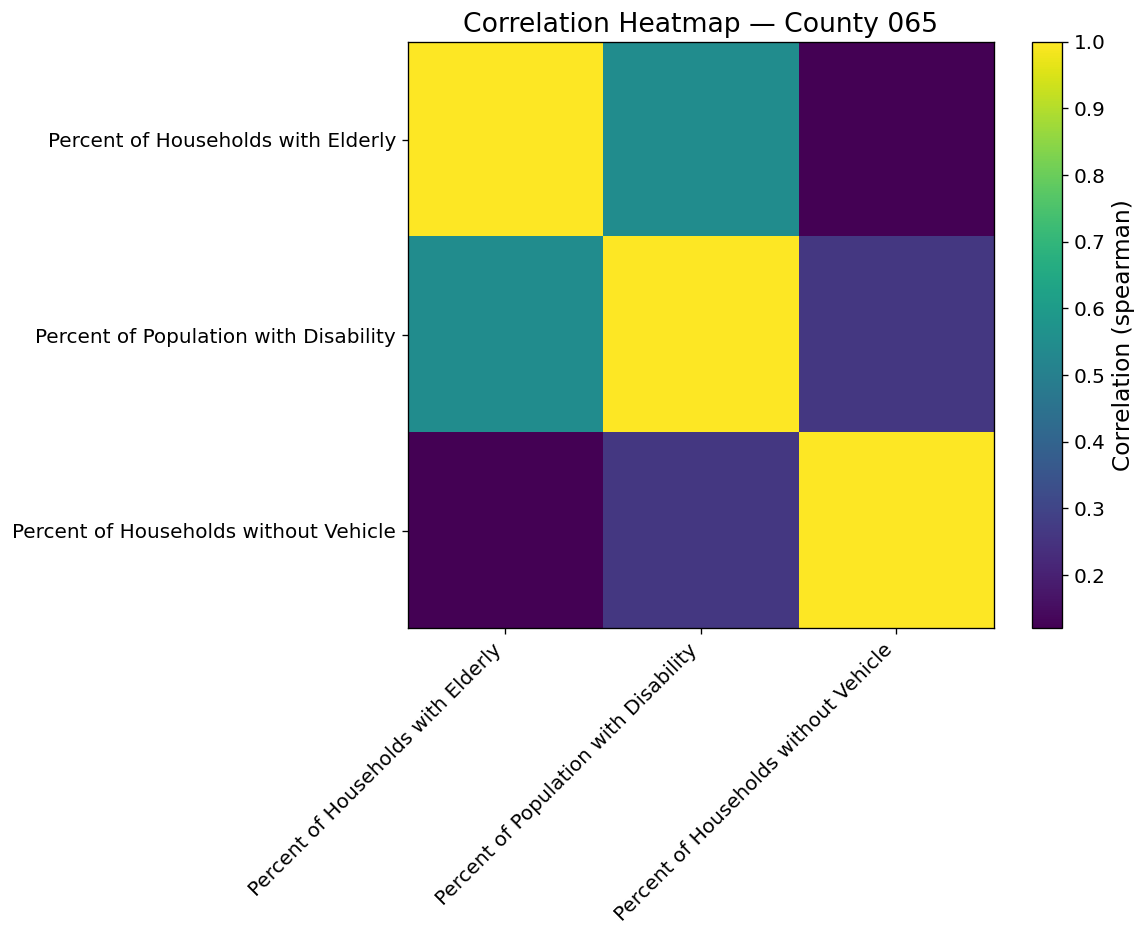

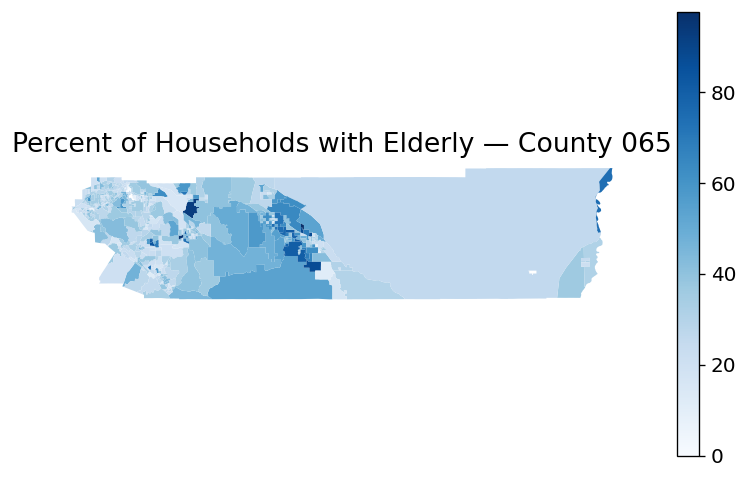

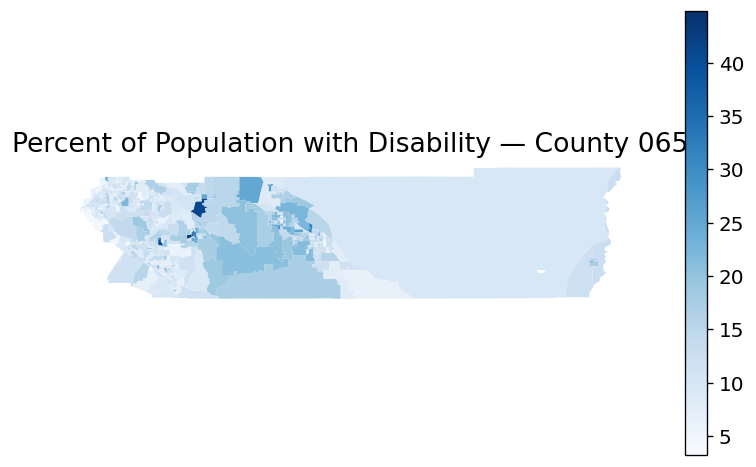

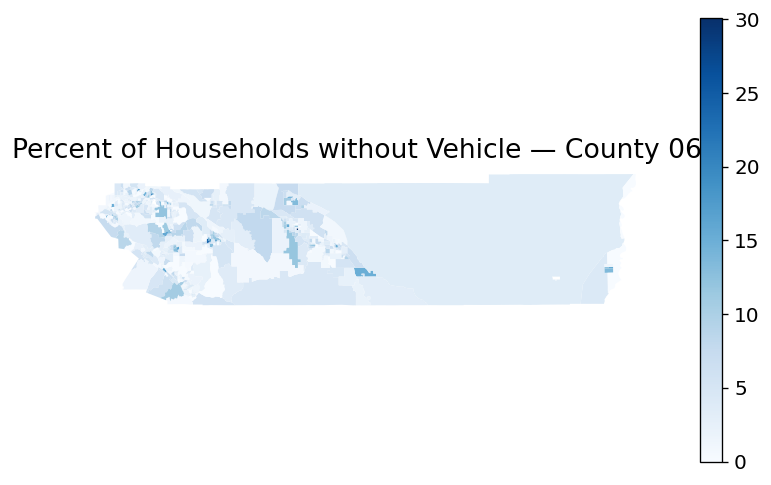

In [19]:
riverside_gdf = eda_plots_for_county(
    census_tract_gdf,
    county_fips="065",
    corr_method="spearman",
    make_static_maps=True
)

**Observations:** Riverside's elderly distribution is shifted rightward compared to the statewide data, centered around 25–35% with a right tail extending to ~100%, likely reflecting retirement communities in the desert region. The disability distribution is right-skewed and similar in shape to the statewide data, extending to about 45%. The no-vehicle distribution is very strongly right-skewed with nearly all tracts below 20%, consistent with the county's car-dependent suburban and exurban character. In the correlation heatmap, elderly and disability show a moderate positive correlation (~0.6), while no-vehicle has near-zero or negative correlation with both — in Riverside, not having a car is relatively uncommon regardless of age or disability status.

### 8.2 San Francisco County (FIPS: 075)

San Francisco is California's most transit-rich county and one of the densest cities in the US.
Its demographic patterns diverge dramatically from the statewide baseline.

County FIPS 075 — 240 tracts


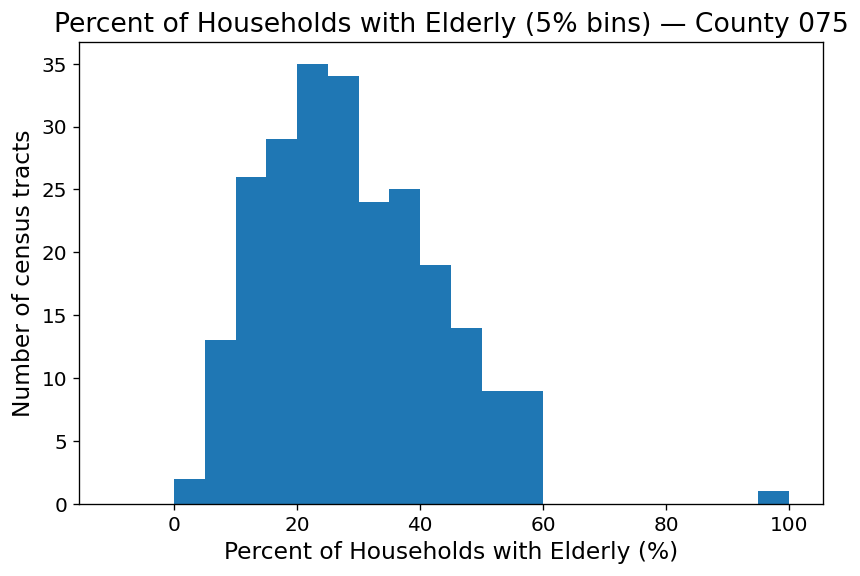

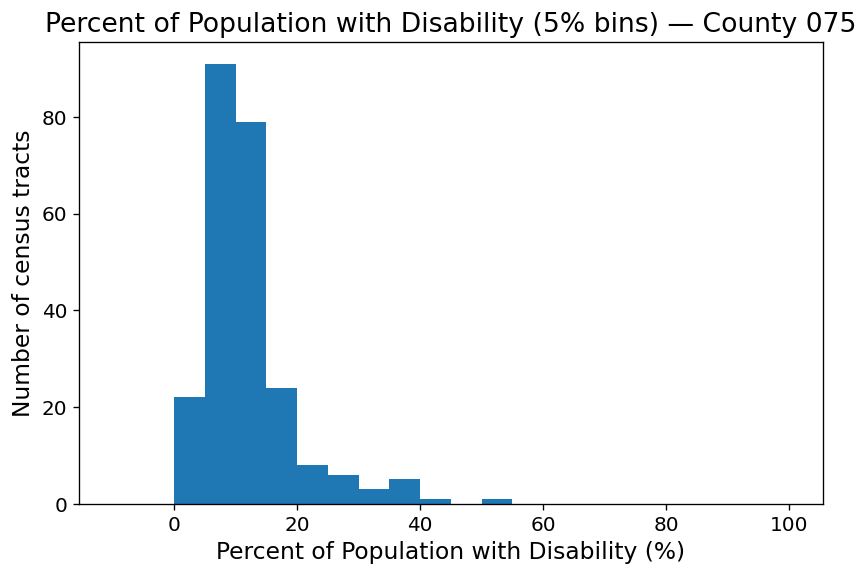

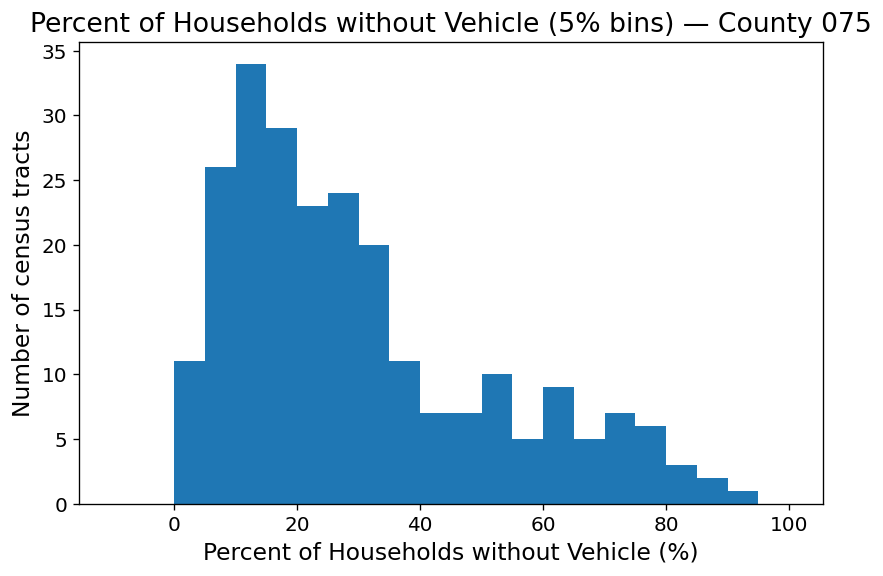

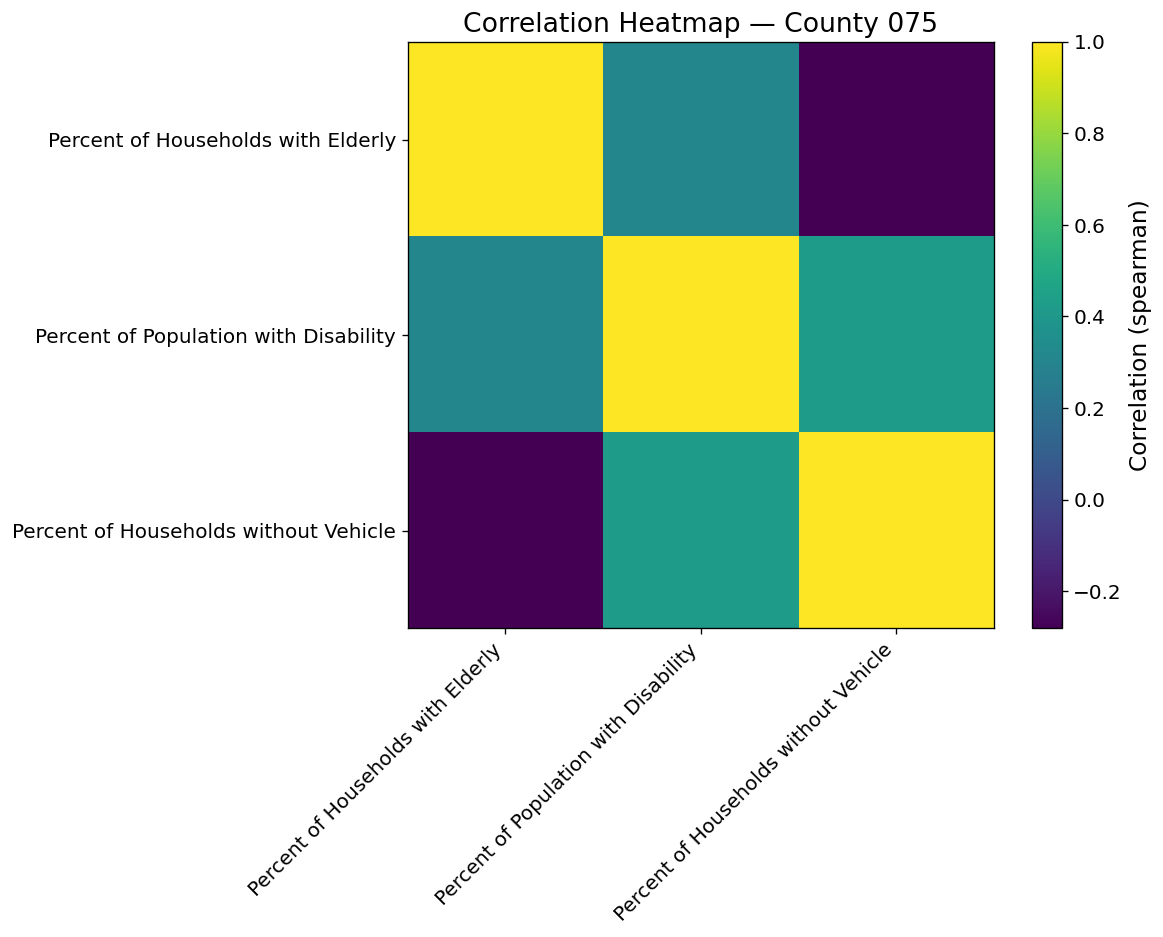

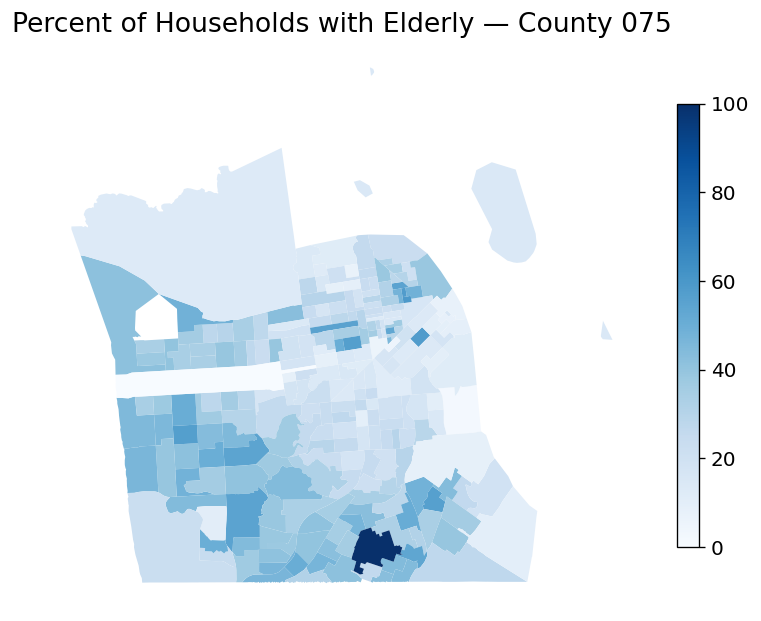

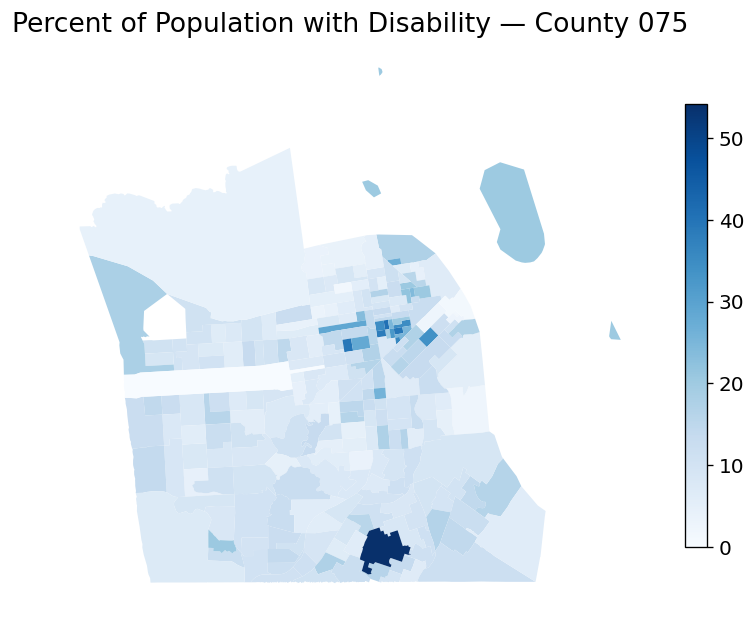

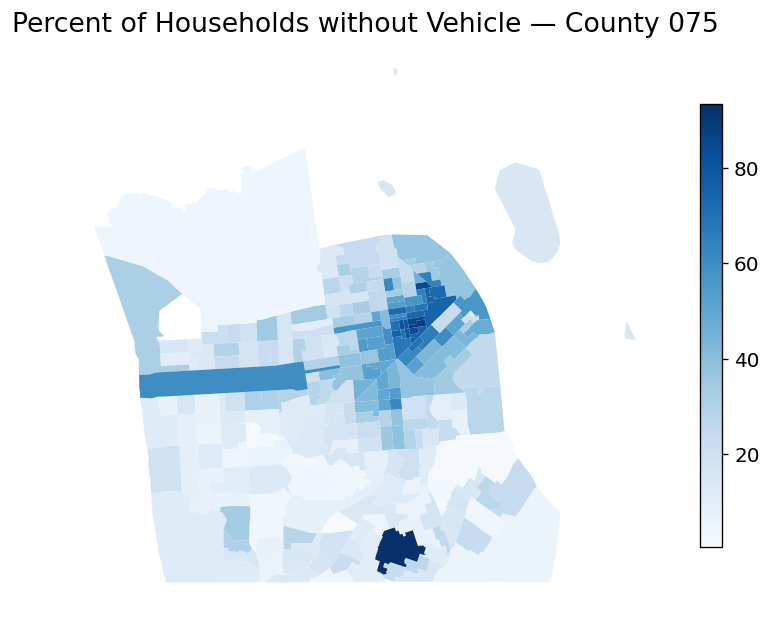

In [20]:
san_francisco_gdf = eda_plots_for_county(
    census_tract_gdf,
    county_fips="075",
    corr_method="spearman",
    make_static_maps=True
)

**Observations:** San Francisco's distributions diverge most strikingly in the **no-vehicle variable**: rather than the extreme right-skew seen statewide, SF's distribution is much more spread out and extends to ~95%, with many tracts above 30–40%. This directly reflects the city's dense transit infrastructure where car-free households are common and functionally viable. The elderly distribution is roughly bell-shaped and centered around 20–30%, similar to the statewide pattern but with a notable outlier tract near 100%. The disability distribution has a longer right tail reaching ~50%, suggesting pockets of very high disability concentration. In the correlation heatmap, **disability and no-vehicle show a moderate positive correlation** (~0.4–0.5) — the inverse of what we see in car-dependent counties — consistent with SF's transit accessibility enabling car-free living across diverse populations.

### 8.3 Placer County (FIPS: 061)

Placer County is a suburban and exurban county northeast of Sacramento, encompassing communities
from Roseville to Lake Tahoe. It is among the most demographically homogeneous of the selected counties.

County FIPS 061 — 91 tracts


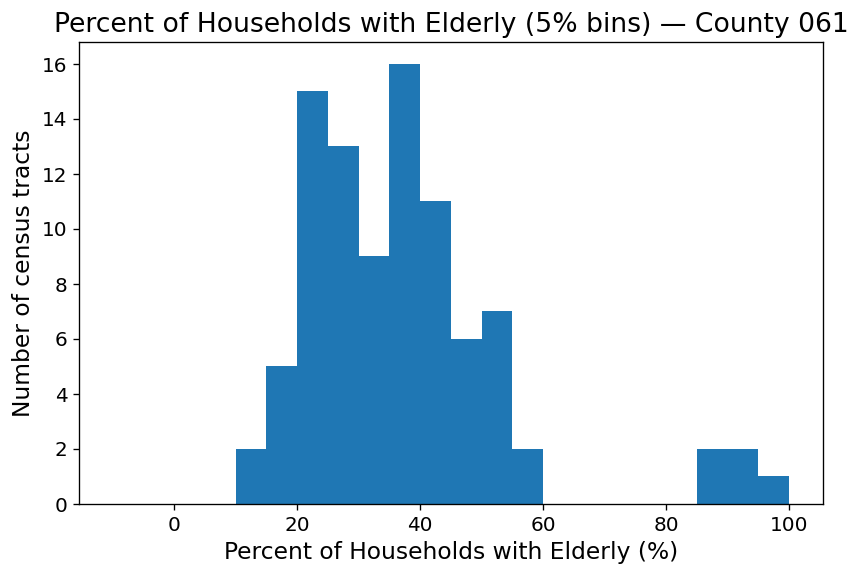

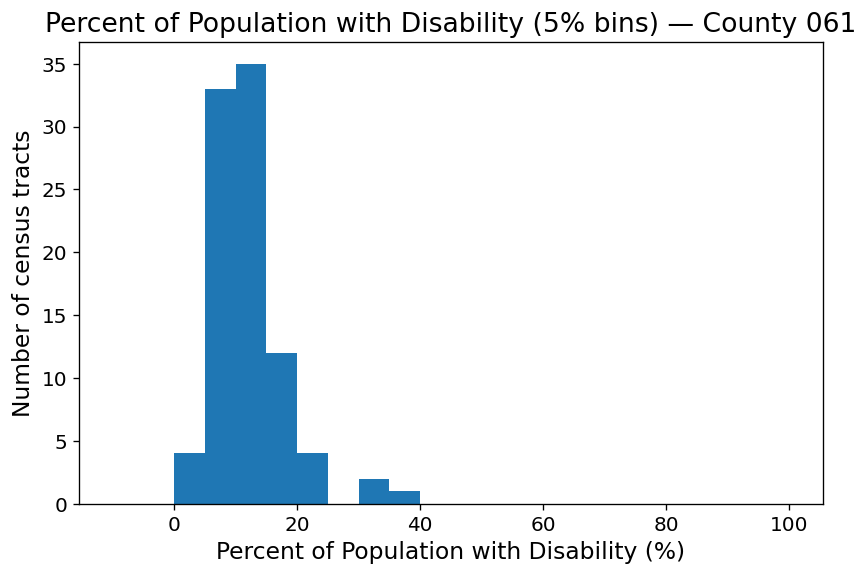

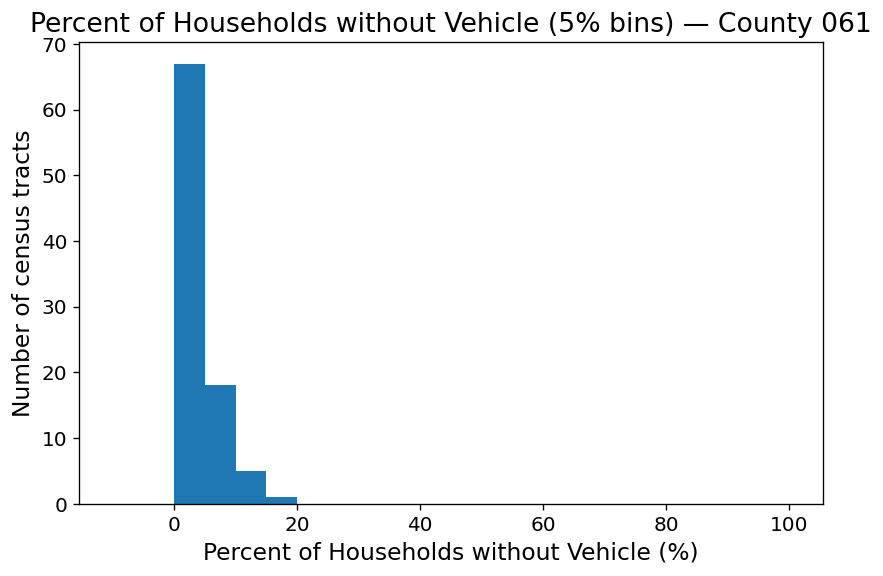

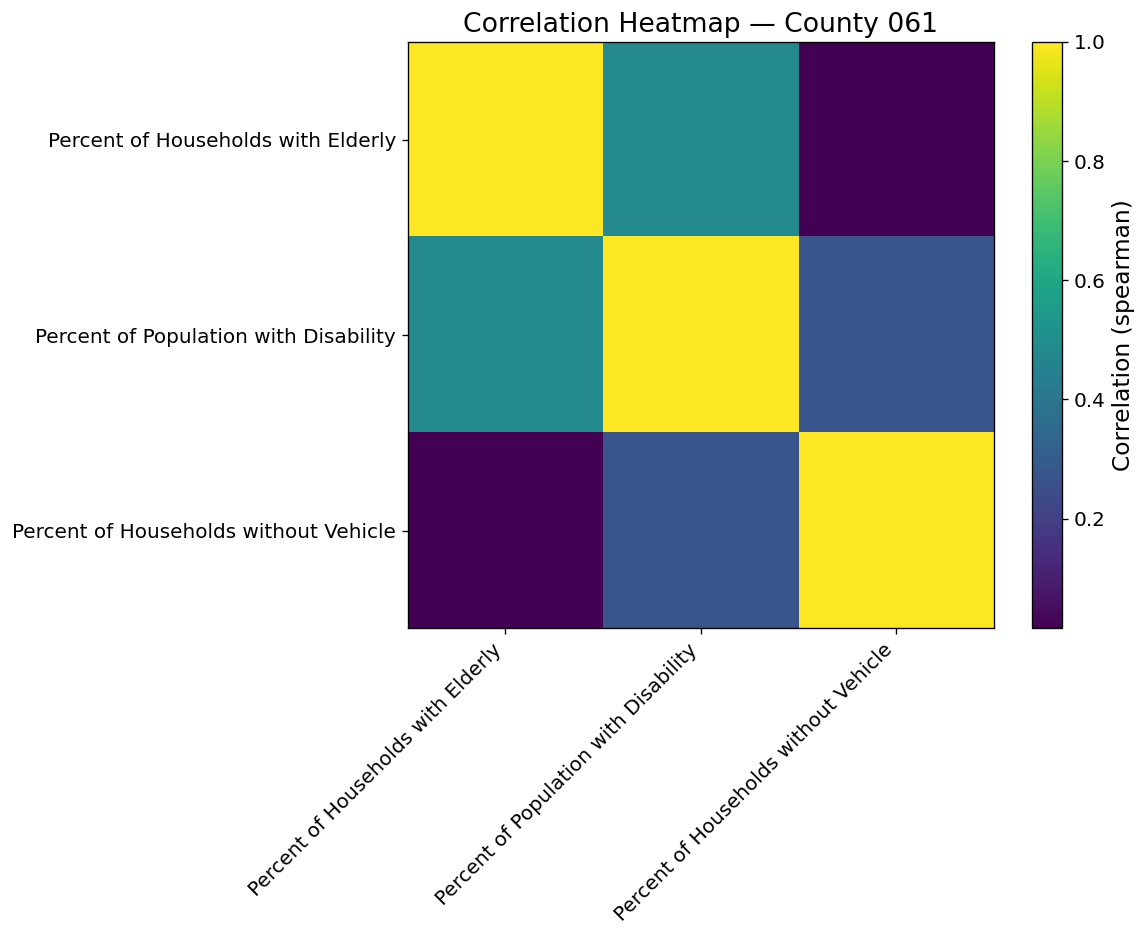

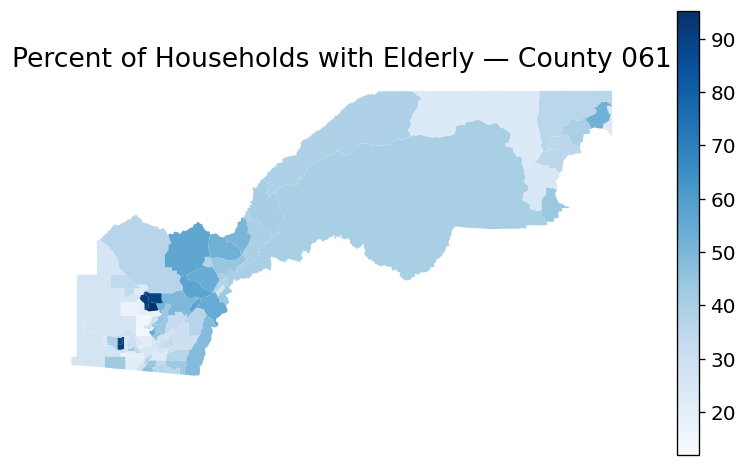

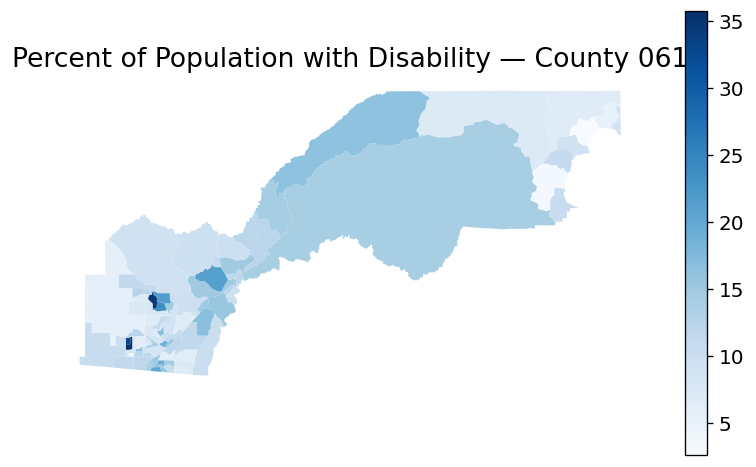

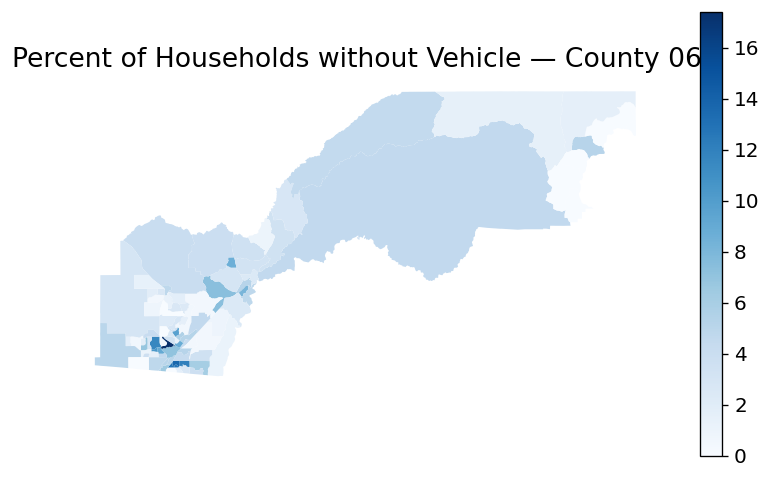

In [21]:
placer_gdf = eda_plots_for_county(
    census_tract_gdf,
    county_fips="061",
    corr_method="spearman",
    make_static_maps=True
)

**Observations:** Placer County shows the most compressed distributions of all five counties. The elderly distribution is roughly bimodal — a main cluster centered around 25–40% and a small secondary cluster near 85–100%, suggesting a mix of typical suburban tracts and a few highly age-concentrated retirement communities. The disability distribution is tightly right-skewed with almost all tracts between 5–20% and very little spread. The no-vehicle distribution is the most compressed of any county, with nearly all tracts in the 0–5% bin — reflecting Placer's almost entirely car-dependent built environment with minimal transit infrastructure. The correlation heatmap mirrors Riverside's: elderly and disability share a moderate positive correlation, while no-vehicle is weakly correlated with either.

### 8.4 Butte County (FIPS: 007)

Butte County is a Northern California rural county that includes Chico and Oroville. It is the site
of the 2018 Camp Fire — the deadliest wildfire in California history — making it a particularly
meaningful county for this evacuation-focused analysis.

County FIPS 007 — 54 tracts


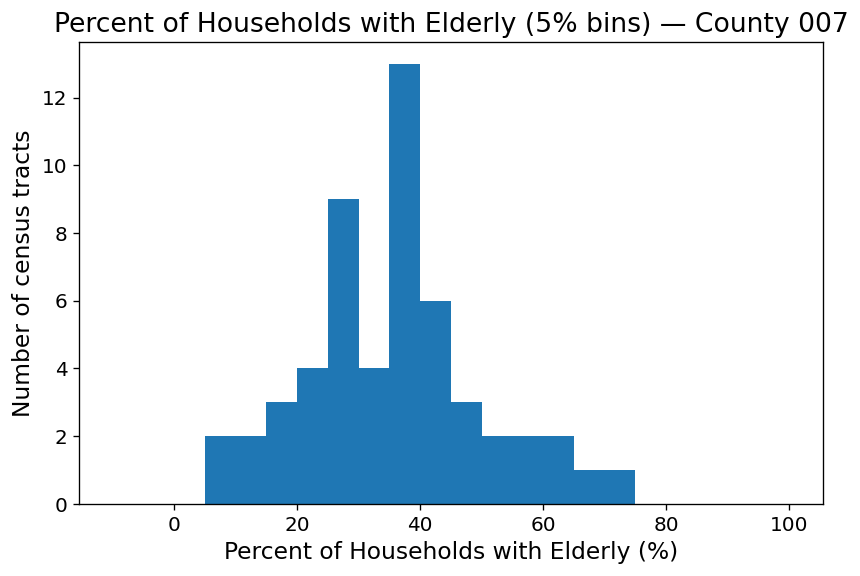

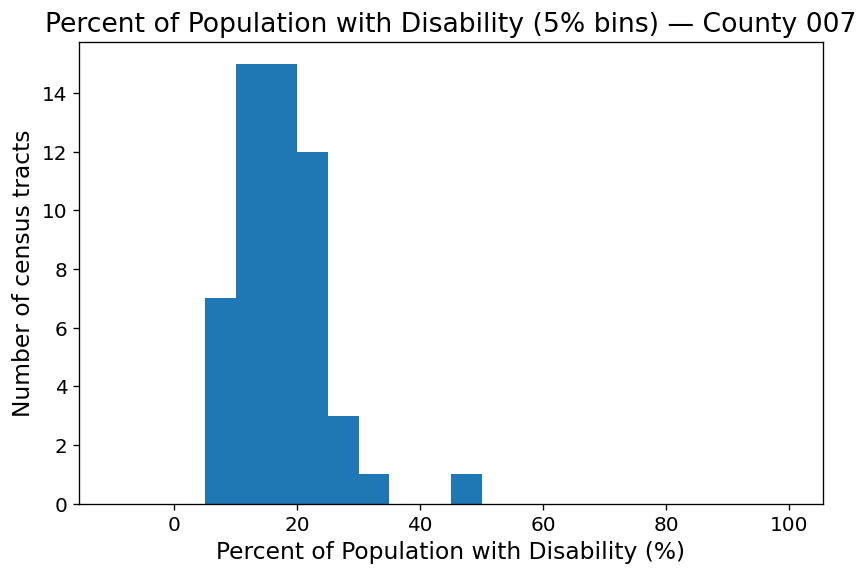

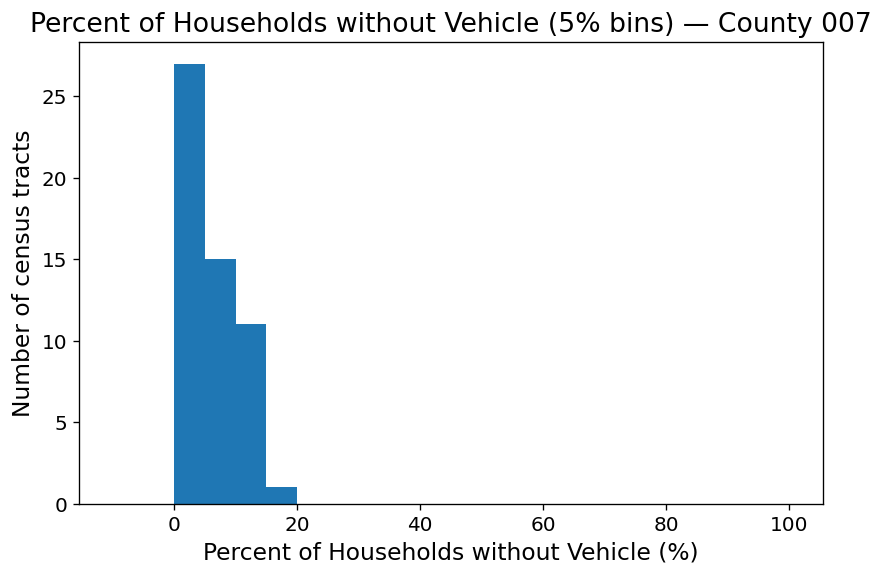

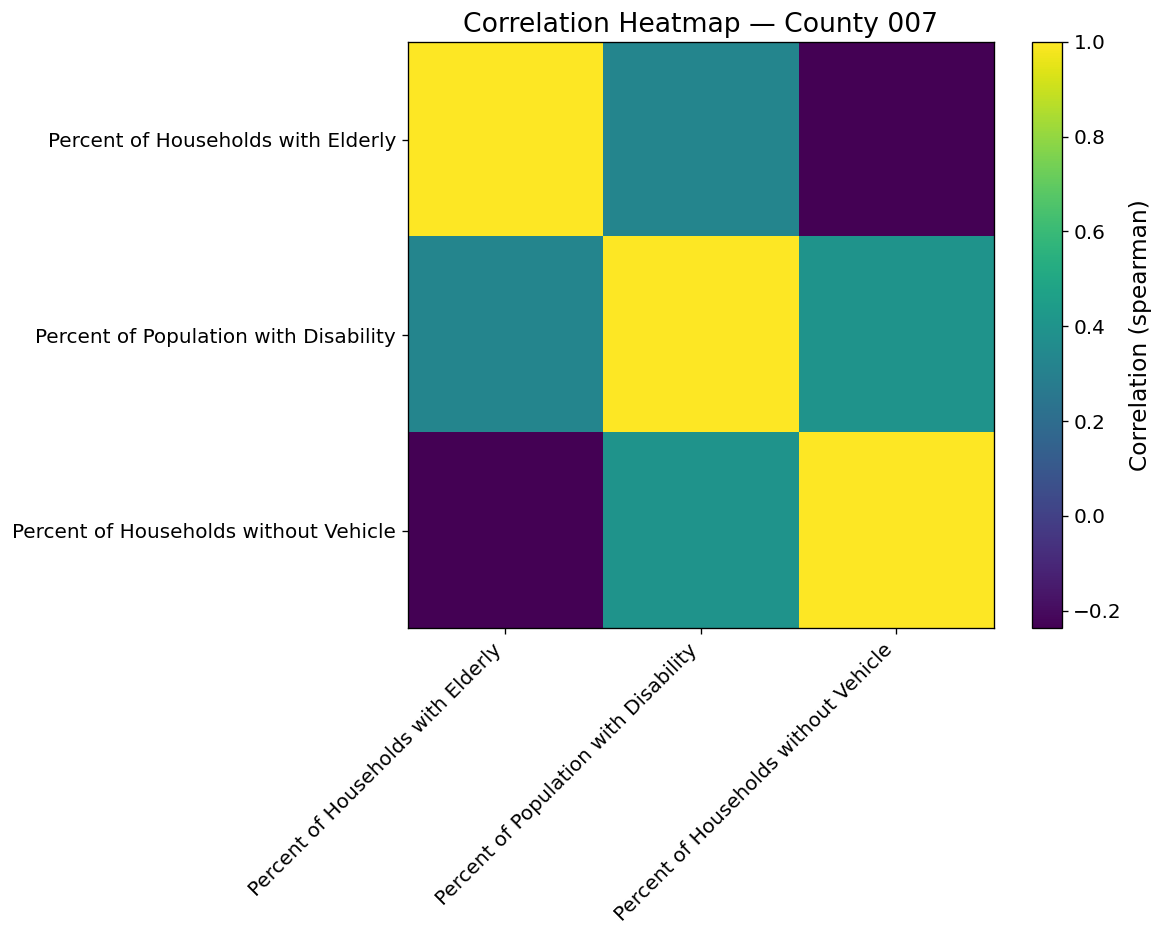

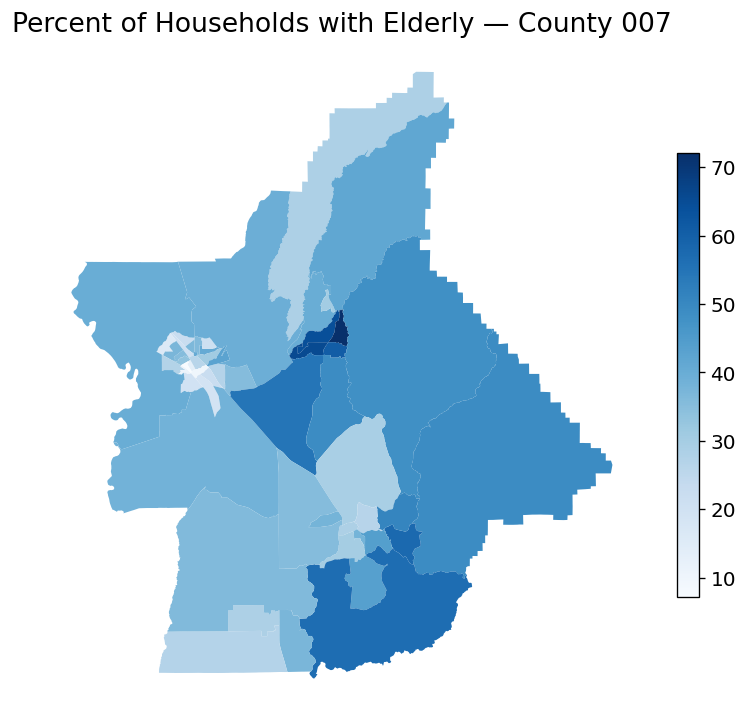

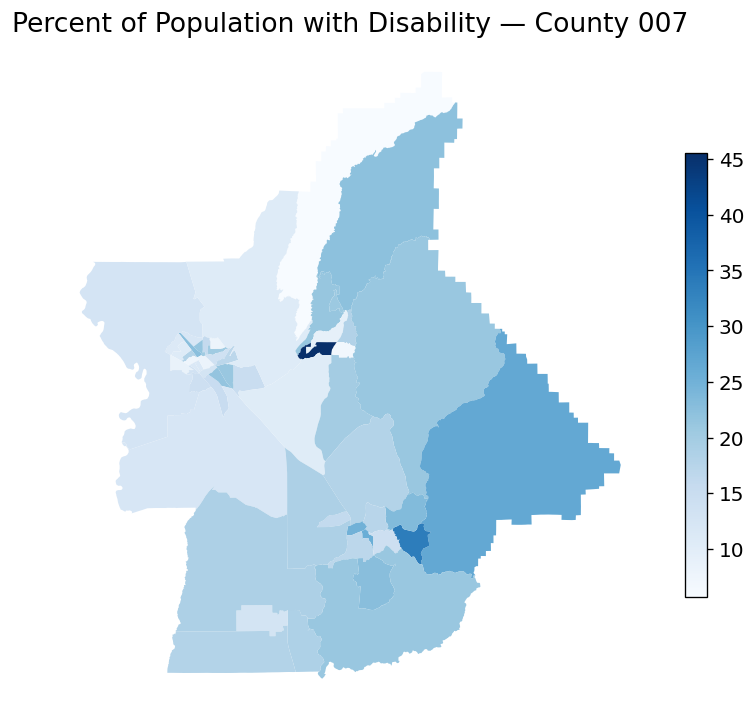

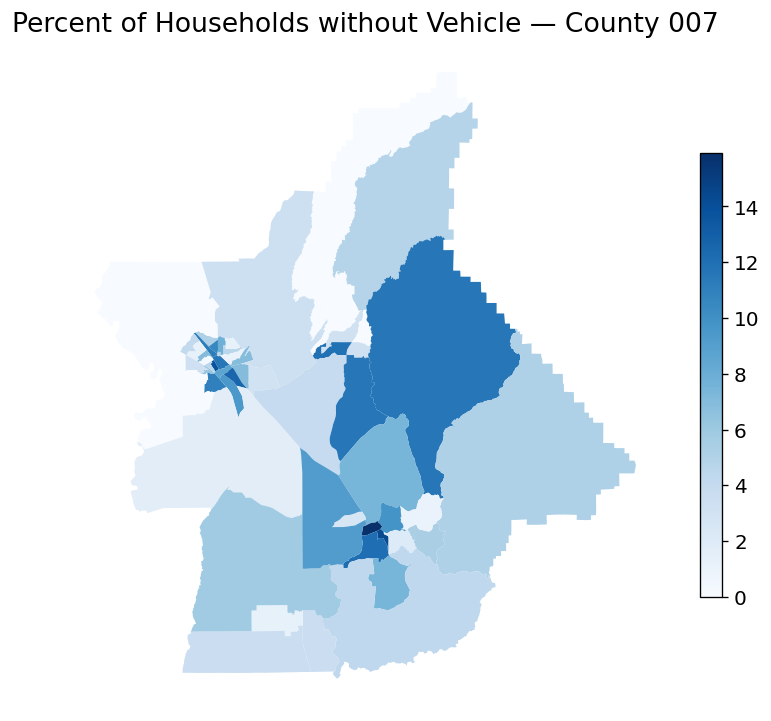

In [22]:
butte_gdf = eda_plots_for_county(
    census_tract_gdf,
    county_fips="007",
    corr_method="spearman",
    make_static_maps=True
)

**Observations:** Butte County's elderly distribution is roughly normally distributed and centered around 35–40% — broadly similar to the statewide distribution but shifted slightly rightward, consistent with an older rural population. There is a slight bimodal shape with a secondary bump in the 25–30% range. The disability distribution is right-skewed with a peak in the 10–20% range and one outlier near 50%, with a heavier right tail than the statewide norm. The no-vehicle distribution is heavily concentrated in the 0–5% bin with a sharp drop-off, cutting off entirely around 20% — reflecting Butte's rural, car-dependent character where high car-free rates are essentially absent. In the correlation heatmap, elderly and disability show a moderate positive correlation (~0.6), and disability and no-vehicle also have a moderate relationship — slightly stronger than seen in Riverside or Placer.

### 8.5 Shasta County (FIPS: 089)

Shasta County is a rural Northern California county anchored by Redding. Like Butte, it has
experienced significant wildfire activity and is highly relevant to this project's focus.

County FIPS 089 — 50 tracts


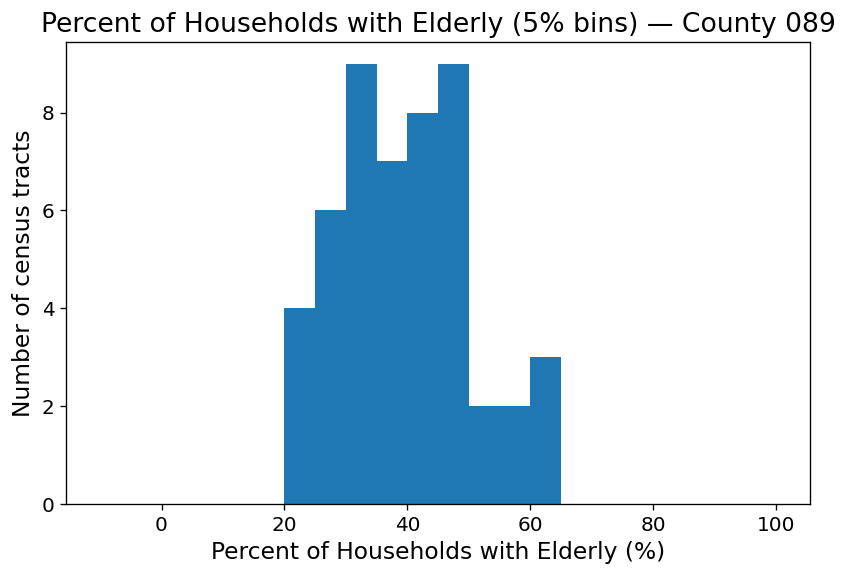

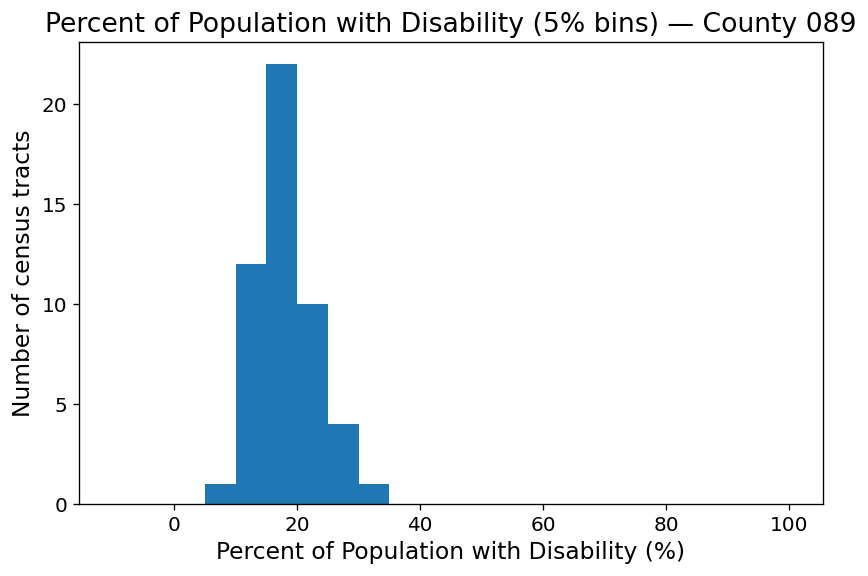

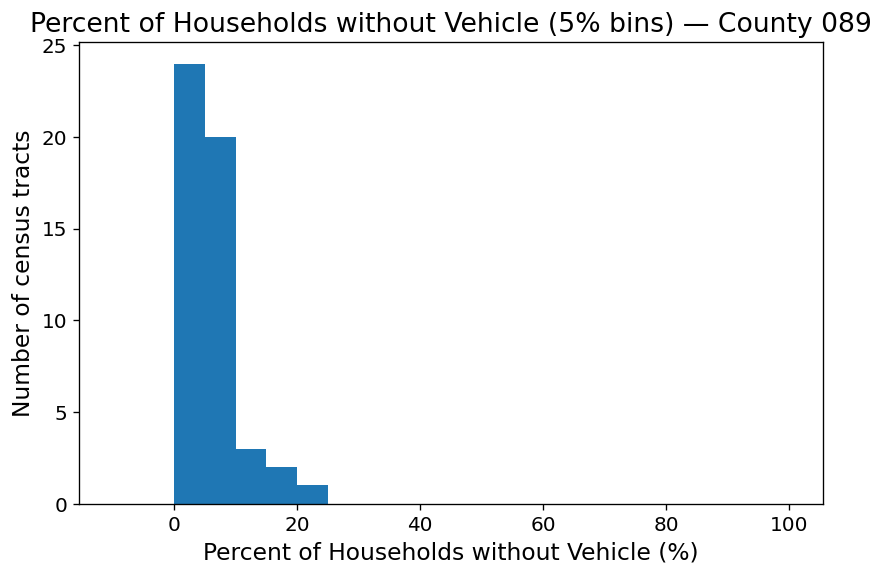

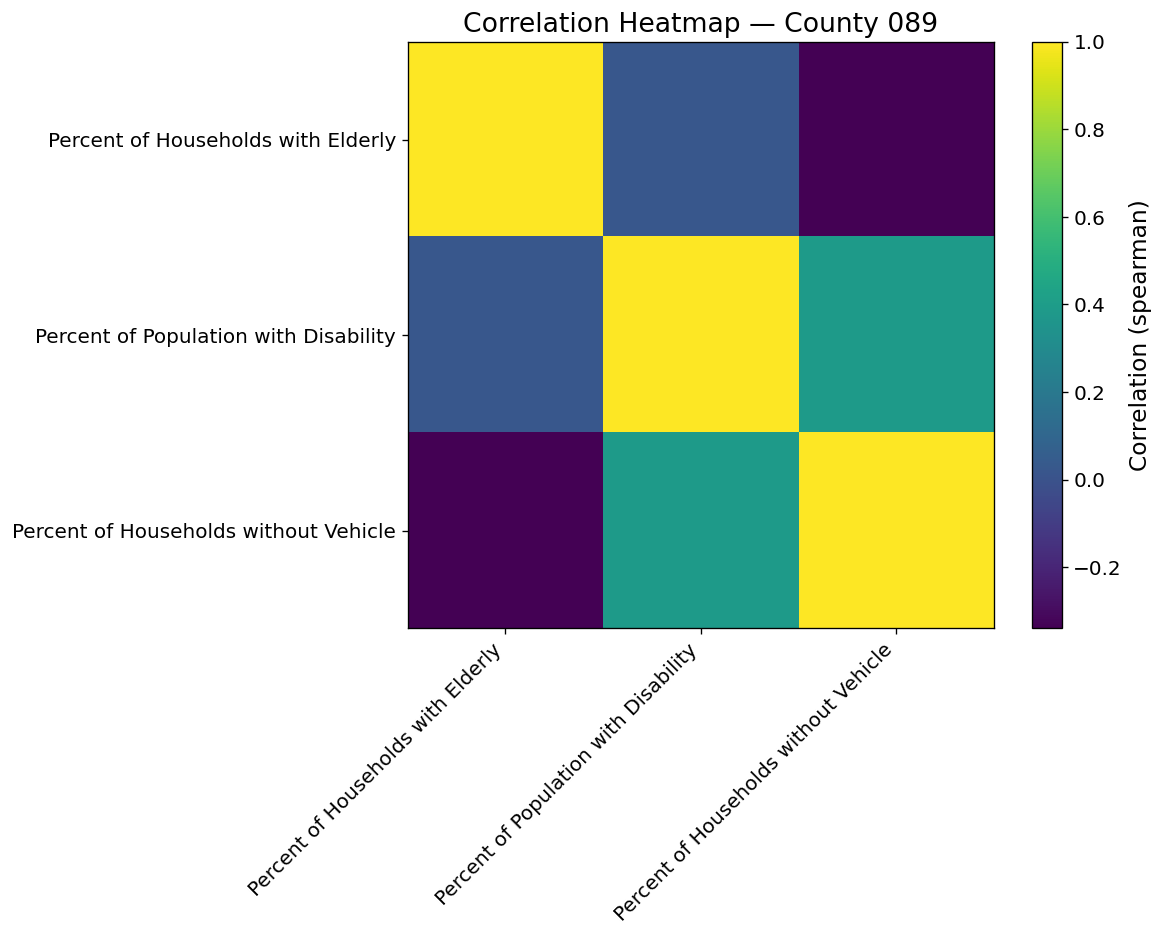

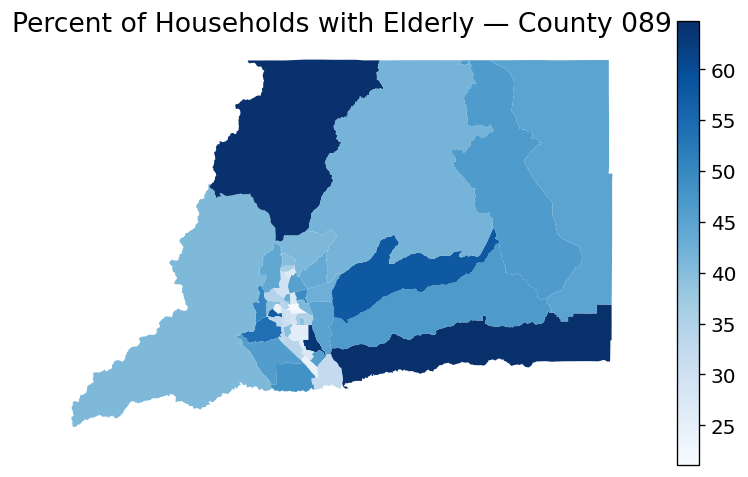

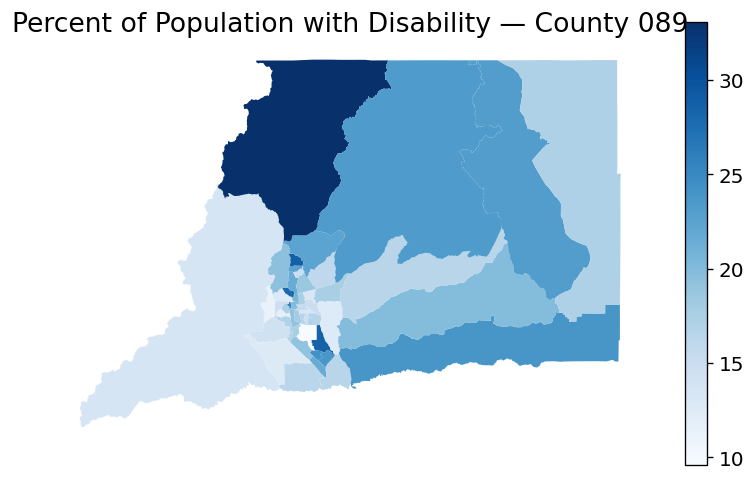

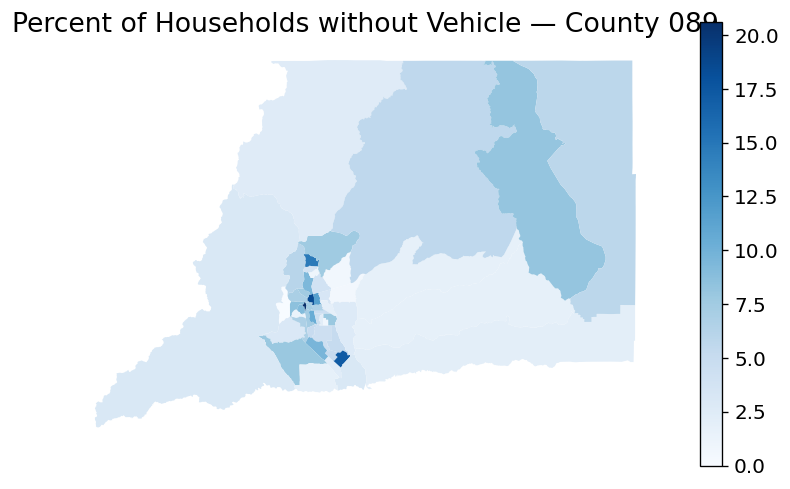

In [23]:
shasta_gdf = eda_plots_for_county(
    census_tract_gdf,
    county_fips="089",
    corr_method="spearman",
    make_static_maps=True
)

**Observations:** Shasta County's elderly distribution is notably shifted rightward compared to the statewide data, centered around 30–45% with values extending to ~65%, reflecting a distinctly older rural population. The disability distribution is right-skewed with a peak in the 15–20% bin, shifted slightly rightward relative to the statewide norm — the bulk of Shasta tracts fall at higher disability rates than most California counties. The no-vehicle distribution is right-skewed and concentrated below 20%, similar to Butte County, consistent with a rural car-dependent county. In the correlation heatmap, **elderly and disability are only weakly correlated** (~0.3–0.4) — notably weaker than Butte or Riverside — while disability and no-vehicle show a moderate positive correlation (~0.4). This suggests that in Shasta, disability-related mobility constraints may be a more independent driver of vehicle access than age alone.

---
## Section 9 · Per-County Q3 Threshold Flagging

### Design Rationale

**Why per-county thresholds?**
California has enormous geographic variability. The county-specific EDA in Section 8 confirmed
that distributions shift dramatically between counties — a "high elderly" rate in Shasta looks
very different from the same rate in San Francisco. Using statewide thresholds would systematically
under-flag rural areas and over-flag dense urban ones. Per-county Q3 thresholds ensure flags mean
*"elevated relative to your local peers."*

**Why Q3 (75th percentile)?**
Q3 marks the top 25% within each county per feature — a focused, actionable signal.
Only tracts that genuinely stand out among their local peers get flagged.
A lower threshold would flag too many tracts to be useful; a higher one would miss
genuinely vulnerable areas in more homogeneous counties like Placer.

### Flag Definitions

| Flag Column | Source Feature | Interpretation |
|---|---|---|
| `flag_high_elderly` | % Households with Elderly | Top 25% in county — above-average share of 65+ residents |
| `flag_high_disability` | % Population with Disability | Top 25% — above-average share of residents with disabilities |
| `flag_low_vehicle_access` | % Households without Vehicle | Top 25% — many households without personal vehicles |

By design, **~25% of tracts per county per flag** will be set. Deviations from 25% indicate tied values at the Q3 boundary.

> #### Note: The flag features computed in the following section are **not used in our final solution**. They are included here as an exploratory tool to help identify and understand demographic vulnerability pockets within each selected county. The EDA above is the primary analytical contribution of this notebook.

In [24]:
# Defining the Flag Features
FLAG_FEATURES = {
    'flag_high_elderly'       : 'Percent of Households with Elderly',
    'flag_high_disability'    : 'Percent of Population with Disability',
    'flag_low_vehicle_access' : 'Percent of Households without Vehicle',
}

# Compute 75th percentile (Q3) per county for each feature
county_q3 = (
    tracts.groupby('county_fips')[list(FLAG_FEATURES.values())]
    .quantile(0.75)
    .rename(columns={v: f'q3_{v}' for v in FLAG_FEATURES.values()})
    .reset_index()
)

# Display thresholds for full transparency
q3_display = county_q3.merge(
    tracts[['county_fips', 'county_name']].drop_duplicates(), on='county_fips'
).set_index('county_name').drop(columns='county_fips').round(2)
q3_display.columns = [
    c.replace('q3_', '').replace('Percent of ', '%')
     .replace(' Households', 'HH').replace(' Population', 'Pop')
    for c in q3_display.columns
]
print('Per-county Q3 flagging thresholds (tracts above these values will be flagged):')
display(q3_display)

Per-county Q3 flagging thresholds (tracts above these values will be flagged):


,%Households with Elderly,%Population with Disability,%Households without Vehicle
county_name,,,
Butte,42.48,21.18,9.43
Placer,43.85,14.45,5.00
Riverside,39.92,15.10,6.10
San Francisco,38.17,13.55,41.42
Shasta,45.98,21.60,7.82


In [25]:
# Merge Q3 thresholds onto tracts and apply binary flags
tracts = tracts.merge(county_q3, on='county_fips', how='left')

for flag_col, feature_col in FLAG_FEATURES.items():
    q3_col = f'q3_{feature_col}'
    tracts[flag_col] = (tracts[feature_col] > tracts[q3_col]).astype(int)

# Drop temporary Q3 columns
q3_cols = [f'q3_{v}' for v in FLAG_FEATURES.values()]
tracts   = tracts.drop(columns=q3_cols)
flag_cols = list(FLAG_FEATURES.keys())

# Verify flag prevalence — each should be ~25%
print('Flag prevalence across all selected tracts:')
flag_summary = tracts[flag_cols].sum().rename('Tracts Flagged').to_frame()
flag_summary['% of Tracts'] = (flag_summary['Tracts Flagged'] / len(tracts) * 100).round(1)
display(flag_summary)

Flag prevalence across all selected tracts:


,Tracts Flagged,% of Tracts
flag_high_elderly,239,25.10
flag_high_disability,237,24.90
flag_low_vehicle_access,235,24.70


In [26]:
# Aggregate total flags per tract and assign preparedness tier
tracts['total_flags'] = tracts[flag_cols].sum(axis=1)

print('Distribution of flag counts per tract:')
display(tracts['total_flags'].value_counts().sort_index().rename('# Tracts').to_frame())

print(f"\nTracts with no flags (typical/below-average on all dimensions): {(tracts['total_flags'] == 0).sum():,}")
print(f"Tracts with all 3 flags (elevated on every dimension):          {(tracts['total_flags'] == 3).sum():,}")

def assign_preparedness_tier(total_flags):
    """
    Assign a qualitative vulnerability tier based on total flag count.
    0-1 flags → Standard Preparedness (typical tract)
    2 flags   → Elevated Concern      (elevated on two vulnerability dimensions)
    3 flags   → High Priority         (top 25% on all three dimensions)
    """
    if total_flags <= 1:
        return 'Standard Preparedness'
    elif total_flags == 2:
        return 'Elevated Concern'
    else:
        return 'High Priority'

tracts['preparedness_tier'] = tracts['total_flags'].apply(assign_preparedness_tier)

print('\nPreparedness tier distribution:')
display(tracts['preparedness_tier'].value_counts().to_frame())

Distribution of flag counts per tract:


,# Tracts
total_flags,
0,487
1,266
2,149
3,49



Tracts with no flags (typical/below-average on all dimensions): 487
Tracts with all 3 flags (elevated on every dimension):          49

Preparedness tier distribution:


,count
preparedness_tier,
Standard Preparedness,753
Elevated Concern,149
High Priority,49


---
## Section 10 · Flag Distribution Visualizations

Three visualizations explore how vulnerability flags are distributed across the selected counties:

1. **Flag Prevalence by County** — what % of tracts in each county carry each flag (dashed line = expected 25%)
2. **Flag Co-occurrence Heatmap** — which vulnerability dimensions tend to cluster on the same tracts
3. **Preparedness Tier Choropleth** — spatial distribution of vulnerability tiers across each county

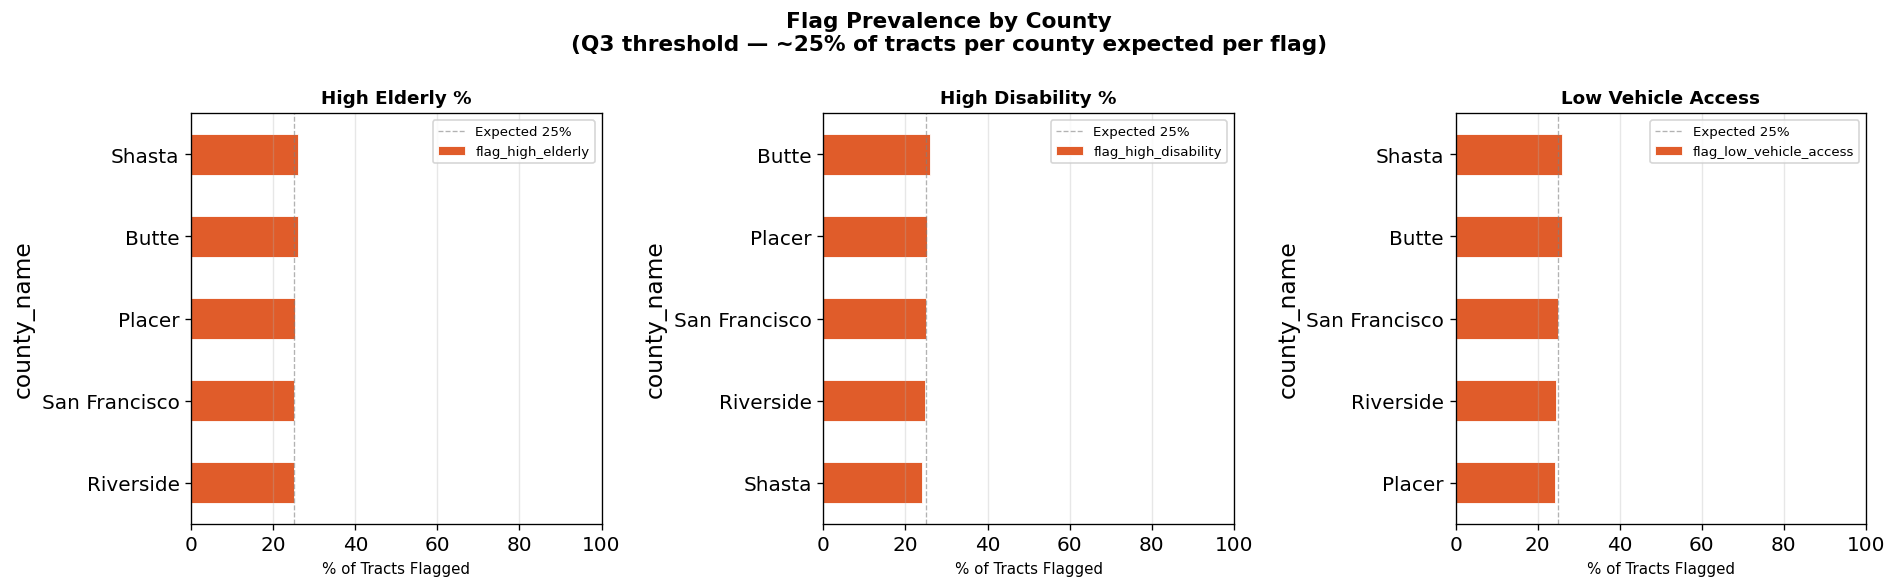

Saved: flag_prevalence_by_county.png


In [ ]:
# ── Figure 1: Flag prevalence by county ──────────────────────────────────
flag_labels = {
    'flag_high_elderly'       : 'High Elderly %',
    'flag_high_disability'    : 'High Disability %',
    'flag_low_vehicle_access' : 'Low Vehicle Access',
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes = axes.flatten()

for ax, (flag_col, label) in zip(axes, flag_labels.items()):
    county_flag_rate = (
        tracts.groupby('county_name')[flag_col].mean() * 100
    ).sort_values(ascending=True)

    county_flag_rate.plot(kind='barh', ax=ax, color='#e05c2a', edgecolor='white', linewidth=0.5)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('% of Tracts Flagged', fontsize=9)
    ax.set_xlim(0, 100)
    ax.axvline(25, color='gray', linestyle='--', linewidth=0.8, alpha=0.6, label='Expected 25%')
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle(
    'Flag Prevalence by County\n(Q3 threshold — ~25% of tracts per county expected per flag)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('flag_prevalence_by_county.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: flag_prevalence_by_county.png")

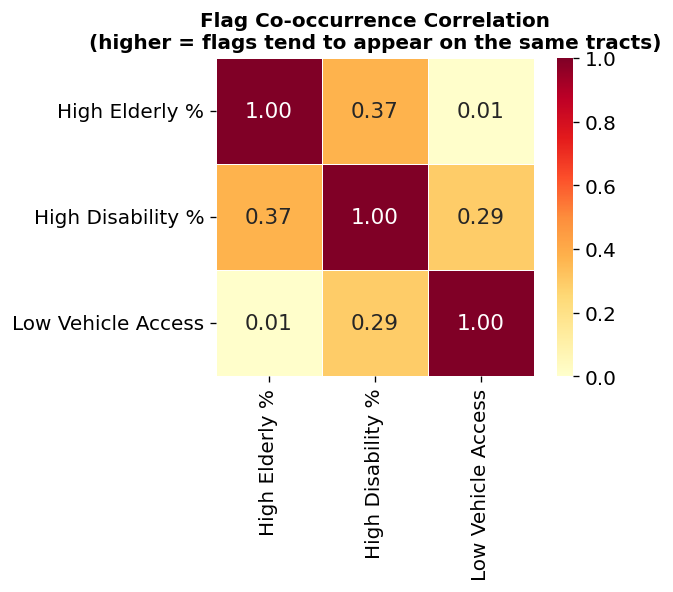

Saved: flag_cooccurrence.png


In [28]:
# ── Figure 2: Flag co-occurrence heatmap ─────────────────────────────────
flag_corr = tracts[flag_cols].rename(columns=flag_labels).corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    flag_corr, annot=True, fmt='.2f', cmap='YlOrRd',
    vmin=0, vmax=1, square=True, linewidths=0.5, ax=ax
)
ax.set_title('Flag Co-occurrence Correlation\n(higher = flags tend to appear on the same tracts)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('flag_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: flag_cooccurrence.png")

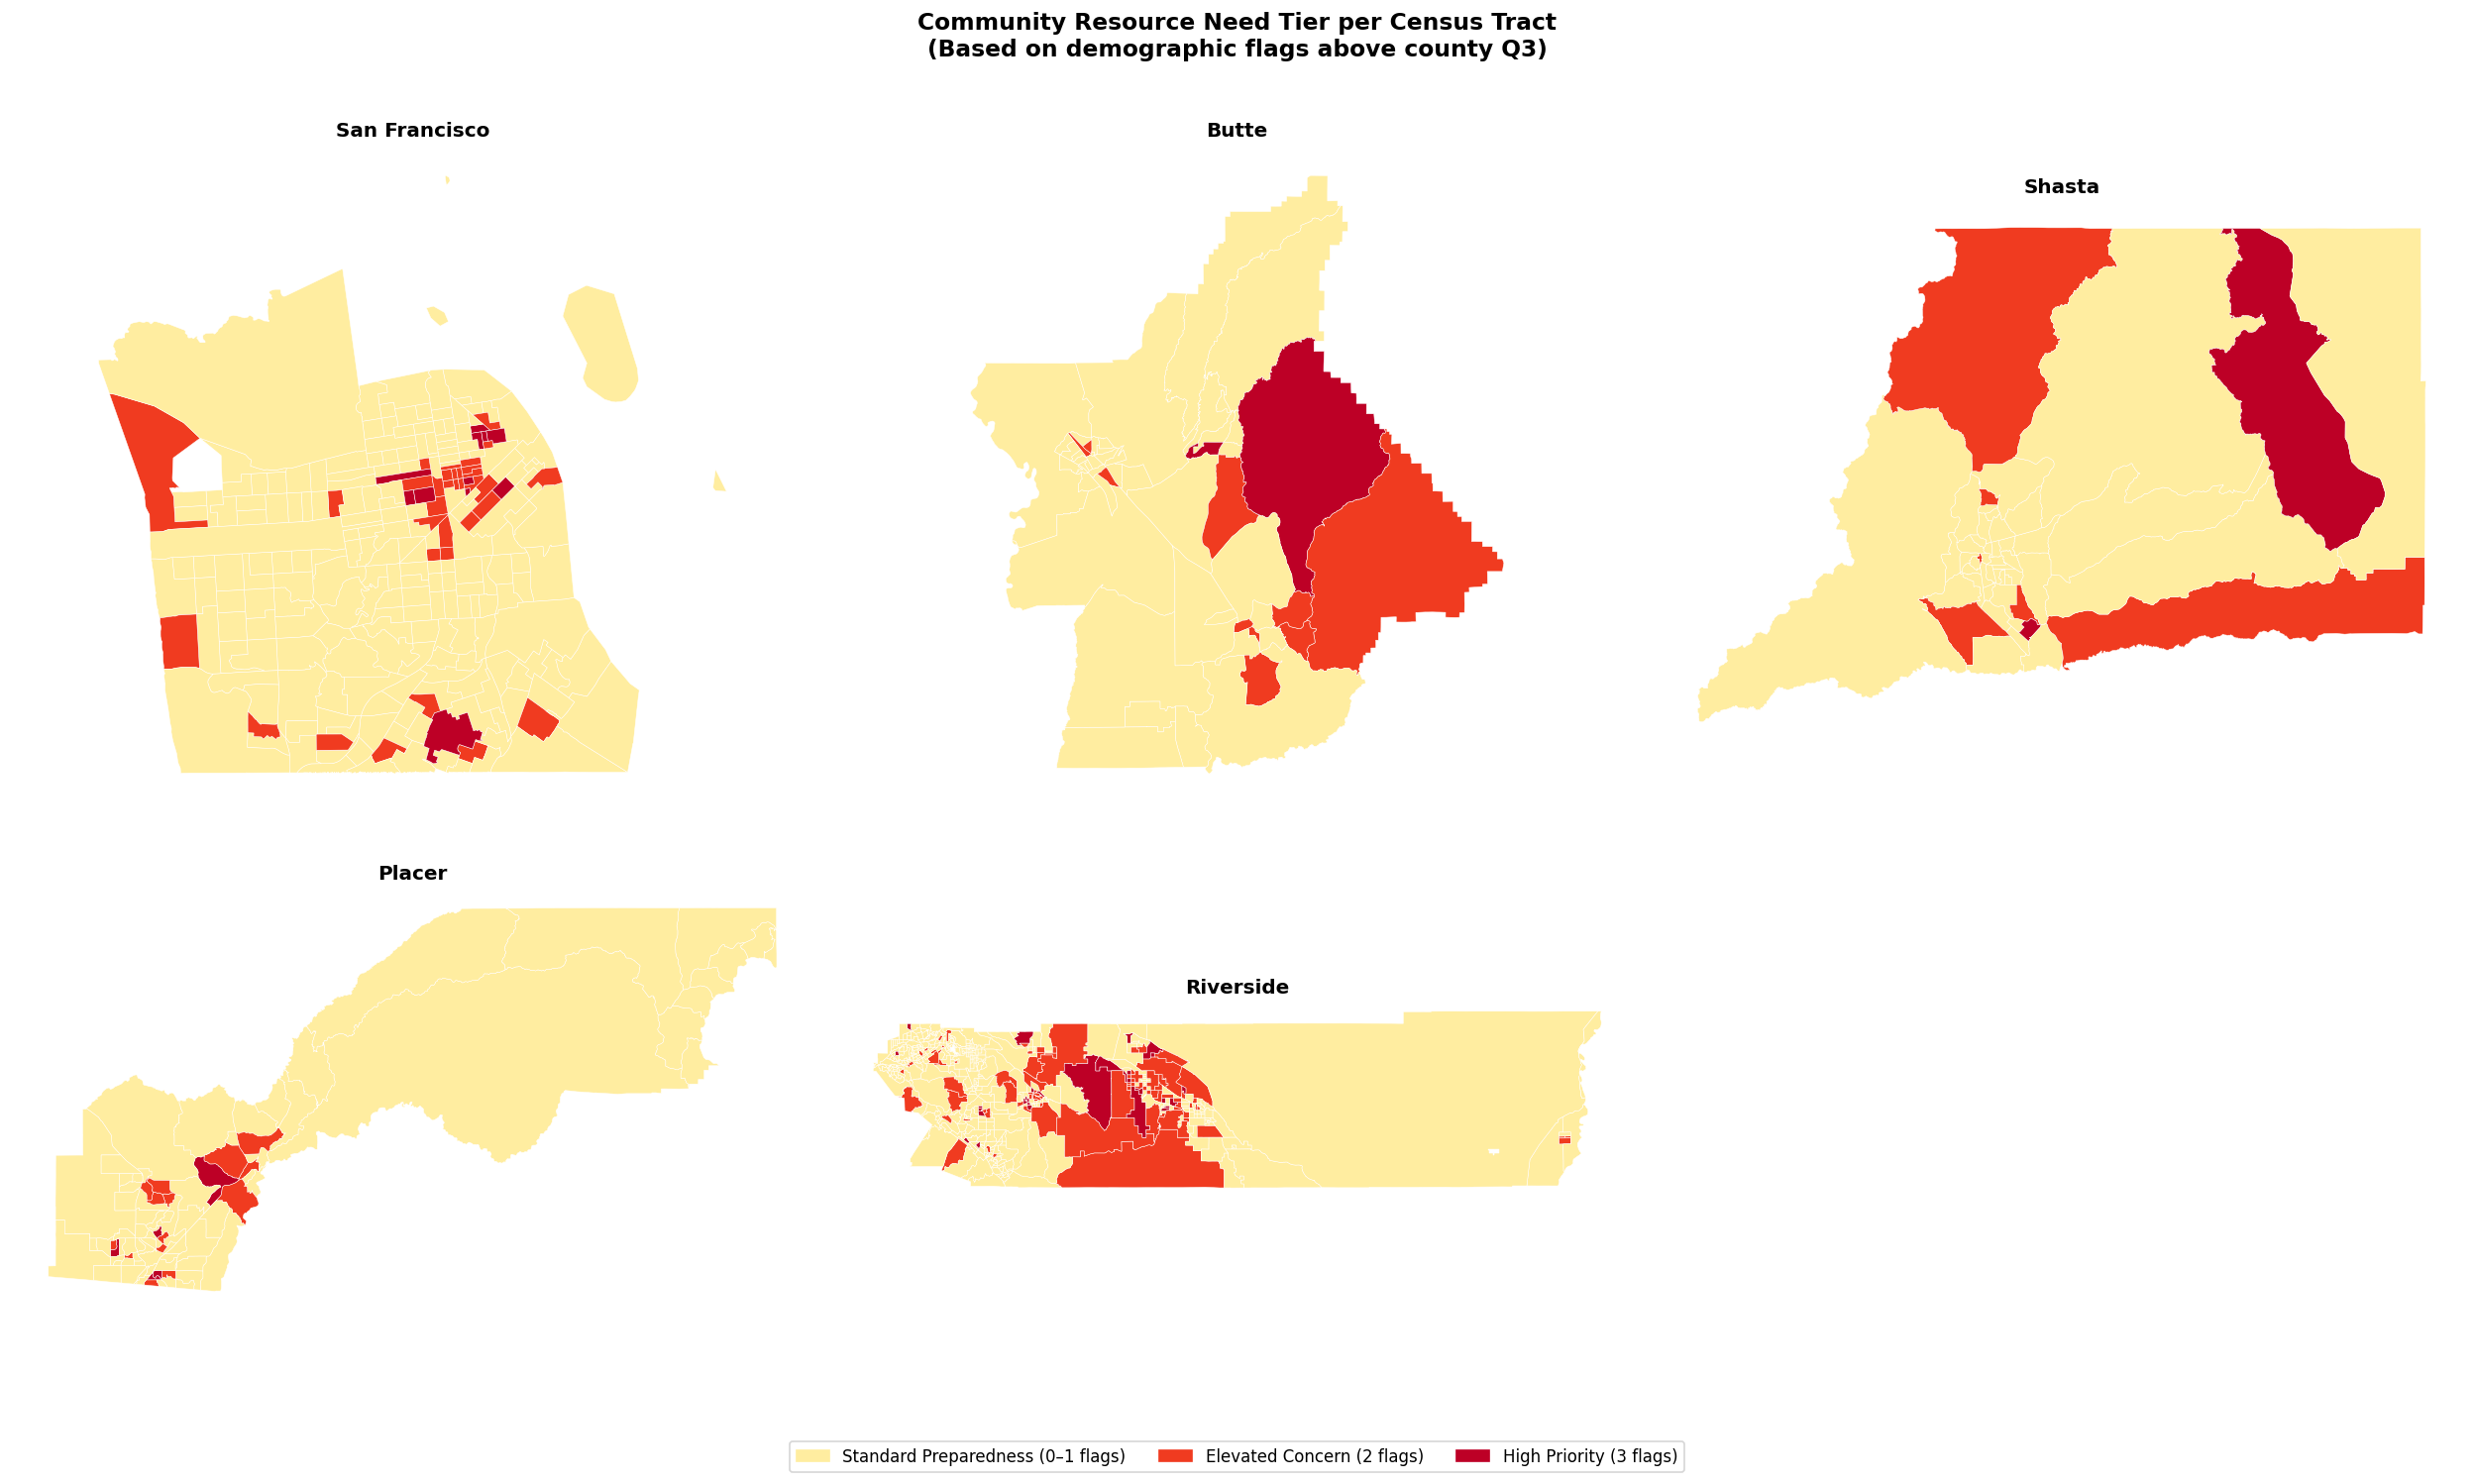

Saved: total_flags_map.png


In [29]:
# ── Figure 3: Choropleth — preparedness tier per tract ───────────────────
import matplotlib.patches as mpatches

tracts_gdf = tracts if isinstance(tracts, gpd.GeoDataFrame) else \
    gpd.GeoDataFrame(tracts, geometry='geometry', crs='EPSG:4326')

tier_colors = {
    'Standard Preparedness': '#FFEDA0',
    'Elevated Concern':       '#F03B20',
    'High Priority':          '#BD0026',
}

ncols = 3
nrows = int(np.ceil(len(top_county_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 6 * nrows))
axes = np.array(axes).flatten()

for idx, (fips, cname) in enumerate(zip(top_county_fips, top_county_names)):
    ax        = axes[idx]
    county_df = tracts_gdf[tracts_gdf['county_fips'] == fips].copy()
    if county_df.empty:
        ax.set_visible(False)
        continue
    county_df['tier_color'] = county_df['preparedness_tier'].map(tier_colors)
    county_df.plot(
        color=county_df['tier_color'], ax=ax,
        edgecolor='white', linewidth=0.3,
        missing_kwds={'color': 'lightgrey'},
    )
    ax.set_title(cname, fontsize=12, fontweight='bold')
    ax.axis('off')

for ax in axes[len(top_county_fips):]:
    ax.set_visible(False)

legend_patches = [
    mpatches.Patch(color='#FFEDA0', label='Standard Preparedness (0–1 flags)'),
    mpatches.Patch(color='#F03B20', label='Elevated Concern (2 flags)'),
    mpatches.Patch(color='#BD0026', label='High Priority (3 flags)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02), frameon=True)
fig.suptitle(
    'Community Resource Need Tier per Census Tract\n'
    '(Based on demographic flags above county Q3)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('total_flags_map.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: total_flags_map.png")

---
## Section 11 · Export Output Files

Two files are exported for downstream use:

### Outputs

| File | Format | Consumer | Purpose |
|---|---|---|---|
| `wildfire_community_tracts.csv` | CSV | LLM matching pipeline | Tabular flag profiles; no geometry needed |
| `wildfire_community_tracts.geojson` | GeoJSON | CERM web map | Tract polygons + all flags for map rendering |

### Column Reference

| Column | Type | Description |
|---|---|---|
| `GEOID` | string | 11-digit Census tract FIPS identifier |
| `NAME` | string | Census tract name |
| `county_fips` | string | 3-digit county FIPS code |
| `county_name` | string | Human-readable county name |
| `Total Population` | int | Tract total population |
| `Percent of Households with Elderly` | float | % households with 65+ resident |
| `Percent of Population with Disability` | float | % population with a disability |
| `Percent of Households without Vehicle` | float | % households without a personal vehicle |
| `flag_high_elderly` | 0/1 | 1 if elderly % > county Q3 |
| `flag_high_disability` | 0/1 | 1 if disability % > county Q3 |
| `flag_low_vehicle_access` | 0/1 | 1 if no-vehicle % > county Q3 |
| `total_flags` | 0–3 | Sum of all three flags |
| `preparedness_tier` | string | Standard Preparedness / Elevated Concern / High Priority |

In [30]:
output_cols = [
    # Identifiers
    'GEOID', 'NAME', 'county_fips', 'county_name',
    # Demographics
    'Total Population',
    'Percent of Households with Elderly',
    'Percent of Population with Disability',
    'Percent of Households without Vehicle',
    # Flags
    'flag_high_elderly',
    'flag_high_disability',
    'flag_low_vehicle_access',
    'total_flags',
    'preparedness_tier',
]

# CSV — for LLM matching pipeline (no geometry needed)
csv_out = tracts[output_cols].copy()
csv_out.to_csv('wildfire_community_tracts.csv', index=False)
print(f'CSV exported: wildfire_community_tracts.csv  ({len(csv_out):,} rows x {len(output_cols)} columns)')

# GeoJSON — for web map (includes geometry)
tracts_gdf = tracts if isinstance(tracts, gpd.GeoDataFrame) else \
    gpd.GeoDataFrame(tracts, geometry='geometry', crs='EPSG:4326')
geojson_out = tracts_gdf[output_cols + ['geometry']].copy()
geojson_out.to_file('wildfire_community_tracts.geojson', driver='GeoJSON')
print(f'\nGeoJSON exported: wildfire_community_tracts.geojson  ({len(geojson_out):,} features)')

CSV exported: wildfire_community_tracts.csv  (951 rows x 13 columns)

GeoJSON exported: wildfire_community_tracts.geojson  (951 features)


In [31]:
# Preview the exported data
print('Output sample (first 10 rows):')
display(
    csv_out[['GEOID', 'county_name'] + flag_cols + ['total_flags', 'preparedness_tier']]
    .head(10)
)

Output sample (first 10 rows):


,GEOID,county_name,flag_high_elderly,flag_high_disability,flag_low_vehicle_access,total_flags,preparedness_tier
0,06007000102,Butte,0,0,0,0,Standard Preparedness
1,06007000103,Butte,0,0,0,0,Standard Preparedness
2,06007000104,Butte,0,0,0,0,Standard Preparedness
3,06007000201,Butte,0,0,0,0,Standard Preparedness
4,06007000202,Butte,0,1,1,2,Elevated Concern
5,06007000300,Butte,0,1,1,2,Elevated Concern
6,06007000401,Butte,0,0,0,0,Standard Preparedness
7,06007000403,Butte,0,0,0,0,Standard Preparedness
8,06007000404,Butte,0,0,0,0,Standard Preparedness
9,06007000501,Butte,0,0,0,0,Standard Preparedness


---
## Section 12 · Results and Validation

### How Community-Based Matching Saves Evacuation Time

| Method | Alignment Score | Demand Coverage |
|---|---|---|
| Random | Low | Low |
| Distance-only | Medium | Low |
| Vulnerability-only | Medium | Medium |
| **Our Method** | **High** | **High** |


> Meeting civilian needs directly correlates with time saved during evacuation according to multiple fire-safety professionals.


### Evaluation Metrics

Since CERM is a **recommendation and matching system** rather than a traditional classification or regression model, standard metrics are adapted to reflect matching quality:

| Metric | Definition | How We Measure It |
|---|---|---|
| **Recommendation Relevance Score** | % of recommended tracts with ≥1 active request matching the helper's parsed service tags | Computed at runtime from tag overlap between LLM-parsed offer and tract request profiles |
| **Demand Coverage** | % of active requests in a tract that are addressed by matched helpers | Tracked via request status transitions: `unsolved → in-progress → solved` |
| **Unfulfilled Request Rate** | % of submitted requests that remain unsolved | High % indicates unmet demand; low % indicates effective matching |
| **Tag Precision** | % of LLM-extracted tags that correctly reflect the user's free-text input | Validated manually on a sample of helper offer submissions |

### Future Evaluation

- **Evacuation Efficiency:** Compare historical vs post-deployment evacuation times
- **Adoption Metrics:** Track growth in website traffic and user sign-ups
- **Helpfulness / Match Quality:** Monitor % of unfulfilled requests
  - High % → unmet demand
  - Low % → effective matching

### Performance Insights

- **Where the tool works well:** High-engagement areas with strong match rates
- **Where the tool struggles:** Low volunteer density and high variability in community needs


---
## Section 13 · Summary & Next Steps

### What This Notebook Produced

| Output | Description |
|---|---|
| `wildfire_community_tracts.csv` | Tract-level vulnerability flags for the LLM matching pipeline |
| `wildfire_community_tracts.geojson` | Spatial file consumed by the CERM web map |
| `flag_prevalence_by_county.png` | Flag rate by county bar chart |
| `flag_cooccurrence.png` | Flag correlation heatmap |
| `total_flags_map.png` | Choropleth of preparedness tiers per county |

### Key Findings from EDA

- **No-vehicle access** is the most geographically variable feature, ranging from near-zero in car-dependent counties (Placer, Riverside) to 40%+ in transit-rich San Francisco, making it the most context-dependent flag
- **Elderly and disability rates** are moderately correlated statewide (~0.4) but this relationship weakens in Shasta, suggesting they capture meaningfully distinct vulnerability in rural contexts
- **Butte and Shasta:** both historically impacted by major wildfires, show elevated disability and elderly rates relative to the statewide norm, reinforcing their relevance to this project
- **All three flags are sufficiently independent:** (no pairwise correlation exceeds 0.5 statewide) to justify using them as separate dimensions in the matching algorithm

### County Selection for the CERM Demo

For the interactive web map, we narrowed the five selected counties down to **Butte, Shasta, and Riverside** as the demo counties. Butte and Shasta were chosen for their direct wildfire history — both have experienced catastrophic fires (the 2018 Camp Fire in Butte; the 2018 Carr Fire in Shasta) and show elevated elderly and disability rates that make evacuation resource matching most consequential. Riverside was chosen to represent a large, car-dependent Southern California county with a high concentration of retirement communities, providing geographic and demographic contrast to the two rural Northern California counties.

### Downstream Handoffs

1. **CERM Web Map** — consumes `wildfire_community_tracts.geojson` for interactive tract visualization and the resource matching interface
2. **LLM Matching Pipeline** — consumes `wildfire_community_tracts.csv` to classify helper offers and match them to highest-need tracts by flag profile

### Potential Extensions

- Add **road network accessibility** data to identify tracts with limited evacuation route options
- Expand to all California counties for statewide coverage
- Integrate **real-time WatchDuty evacuation alerts** to dynamically update tier assignments during active events

---

## Team Contributions

| Name             | Contributions                                                                  |
|------------------|--------------------------------------------------------------------------------|
| Riya Bharathwaj  | EDA, Feature engineering, modeling, building solution, presentation prep       |
| Ting-ya Chang    | EDA, geospatial joins, Research/Outreach, building solution, presentation prep |
| Saehee Eom       | EDA, Feature engineering, modeling, building solution, presentation prep       |
| Tanmayee Kolli   | EDA, Research/Outreach, building solution, presentation prep                   |
| Simran Mallik    | EDA, preprocessing, Research/Outreach, building solution, presentation prep    |